# 3 · Validação de Hipóteses

Levantamos novas hipóteses a partir da análise exploratória e precisamos as testar para verificar se elas fazem sentido.

## Nossas Hipóteses

## Resultado

| # | Hipótese | Veredito |
|---|---|---|
| 1 | O banco não é o principal do cliente | Confirmada |
| 2 | Quem ficou migrou de cartão para PIX |  no agregado sim, no cliente não |
| 3 | A safra de 2023 transacionava pouco e por isso parou de pedir cartão | Refutada |
| 4 | Não há churn, caiu share-of-wallet | Confirmada |
| 5 | Usaram mais PIX, menos cartão, e menos o banco em geral | Parte Verdade |
| 6 | 1 em cada 10 PIX reprovado indica baixa maturidade digital | Essa não parece ser a causa|
| 7 | PIX para a própria conta subiu de 10% para 16% | Dados Inconclusivos |
| 8 | O cadastro incompleto impede o cliente de investir | Confirmada |
| 9 | O dinheiro está saindo pelos investimentos | Na verdade a captação de investimentos parece estar positiva |

## Sobre os Dados

Para o tratamento, nosso foco foi tentar solucionar 3 problemas que identificamos:

1. A base PIX não tem jan–jul/2025 e muda de patamar em 2025-08
2. O valor da transação de cartão foi sorteado (distribuição uniforme), não observado
3. A escala do PIX mudou 4,13× em 2025-08 


In [5]:
# =============================================================================
# Setup
# =============================================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.width', 210)
pd.set_option('display.max_columns', 60)

PASTA = Path('.')

C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = C
INK, INK2, INK3, GRID, SURF = '#0b0b0b', '#52514e', '#8a8880', '#e6e5e1', '#fcfcfb'

mpl.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'axes.edgecolor': GRID, 'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.titlelocation': 'left', 'axes.labelsize': 9.5, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.major.size': 0, 'ytick.major.size': 0, 'legend.frameon': False,
    'lines.linewidth': 2.0, 'font.size': 10, 'figure.dpi': 110,
})

def eixo(ax, titulo=None, sub=None, ylab=None, xlab=None):
    if titulo: ax.set_title(titulo, pad=28 if sub else 14)
    if sub:
        ax.annotate(sub, xy=(0, 1), xycoords='axes fraction', xytext=(0, 8),
                    textcoords='offset points', fontsize=9.5, color=INK2, va='bottom')
    ax.set_ylabel(ylab or ''); ax.set_xlabel(xlab or '')
    return ax

def n(x):     return f'{x:,.0f}'.replace(',', '.')
def brl(x):   return ('R$ %s' % f'{x:,.2f}').replace(',', '@').replace('.', ',').replace('@', '.')
def pct(x):   return f'{x:.1f}%'.replace('.', ',')
FMT_PCT = FuncFormatter(lambda v, p: f'{v:.0f}%')
FMT_MIL = FuncFormatter(lambda v, p: f'{v:,.0f}'.replace(',', '.'))
FMT_BRL = FuncFormatter(lambda v, p: (f'R$ {v/1e6:.1f} mi'.replace('.', ',') if abs(v) >= 1e6
                                      else f'R$ {v:,.0f}'.replace(',', '.')))

VEREDITOS = []
def veredito(num, titulo, resultado, resumo):
    '''Registra e imprime o veredito de uma hipótese.'''
    VEREDITOS.append(dict(Hipotese=num, Titulo=titulo, Veredito=resultado, Resumo=resumo))
    selo = {'CONFIRMADA':'','PARCIALMENTE CONFIRMADA':'','NÃO CONCLUSIVA':'','REFUTADA':''}[resultado]
    print(f'\n{"═"*76}\n  {selo}  H{num} — {resultado}\n{"─"*76}\n  {resumo}\n{"═"*76}')

print('Ambiente pronto.')

Ambiente pronto.


---
## Carga com as bases tratadas

Este notebook lê `bases_tratadas/`, produzido pelo notebook `2_limpeza_de_dados.ipynb`.As flags criadas lá permitem excluir dado corrompido de cada teste sem apagar nada, e a coluna `Valor_norm` permite comparar valores de PIX ao longo da série.

In [6]:
# =============================================================================
# Carga das bases tratadas
# =============================================================================
B = PASTA / 'bases_tratadas'
assert B.exists(), 'Rode o notebook 2_limpeza_de_dados.ipynb antes deste.'

clientes = pd.read_csv(B/'clientes_tratado.csv',      parse_dates=['Data_Nascimento','Data_Criacao_Conta'])
cartoes  = pd.read_csv(B/'cartoes_tratado.csv',       parse_dates=['Data_Emissao','Data_Ativacao','Data_Validade'])
transac  = pd.read_csv(B/'transacoes_tratado.csv',    parse_dates=['Data'])
pix      = pd.read_csv(B/'pix_tratado.csv',           parse_dates=['Data'])
invest   = pd.read_csv(B/'investimentos_tratado.csv', parse_dates=['Data','Data_de_vencimento'])

#  Recortes limpos, usados em todo o notebook 
# Cartão: só o que o banco autorizou
CART = transac[transac.Autorizado == True].copy()

# PIX: aprovado, com data, com tipo, e sem os valores corrompidos
PIX_OK = pix[(pix.Aprovado == True) & (~pix.flag_valor_impossivel)
             & (~pix.flag_sem_data) & (~pix.flag_sem_tipo)].copy()

for d in (CART, PIX_OK):
    d['trim']     = d.Data.dt.to_period('Q')
    d['mes']      = d.Data.dt.to_period('M')
    d['semestre'] = d.Data.dt.year.astype(str) + 'S' + ((d.Data.dt.month > 6).astype(int) + 1).astype(str)

invest['trim'] = invest.Data.dt.to_period('Q')
invest['mes']  = invest.Data.dt.month
invest['ano']  = invest.Data.dt.year

def rot_trim(p): return f'{p.quarter}T{str(p.year)[2:]}'

print(f'  Cartão  · transações autorizadas : {n(len(CART))}')
print(f'  PIX     · transações utilizáveis : {n(len(PIX_OK))}   '
      f'({n(len(pix)-len(PIX_OK))} descartadas do recorte por flag, mas presentes na base)')
print(f'  Investimentos                    : {n(len(invest))}')
print(f'  Clientes                         : {n(len(clientes))}')

  Cartão  · transações autorizadas : 155.987
  PIX     · transações utilizáveis : 249.655   (29.285 descartadas do recorte por flag, mas presentes na base)
  Investimentos                    : 21.200
  Clientes                         : 1.960


---
# 1 · O Priceless Bank não é o banco principal do cliente

> Nossa hipótese é que as contas existem e são usadas, mas o cliente mantém o dinheiro dele em outro lugar.

Pensamos que: se um banco é o principal de alguém, três coisas devem aparecem nos dados: o salário cai
lá, o dinheiro fica lá, e as entradas cobrem as saídas.

O mais próximo de salário disponível é o recebimento de PIX vindo de PJ, repetido todo mês.

  Recebimentos são 11.8% das transações PIX  (29.370 de 249.655)

  Procurando um padrão de salário — recebimento de PJ todo mês:
    clientes com recebimento PJ em ≥80% dos meses ativos : 62 de 1427  (4.3%)
    cobertura mediana (meses com PJ ÷ meses ativos)      : 27.6%
    valor mediano do recebimento de PJ                   : R$ 160,05

  → Só 4% dos clientes recebem de PJ com regularidade mensal.
  → E o valor mediano é R$ 160,05.
  Saída por PIX   : R$ 55.758.840,42
  Entrada por PIX : R$ 7.578.557,53
  Razão           : para cada R$ 1,00 que entra, saem R$ 7,36

  Clientes com fluxo líquido de PIX NEGATIVO: 1430 de 1430  (100.0%)

  → Não existe um cliente que receba mais PIX do que envia.


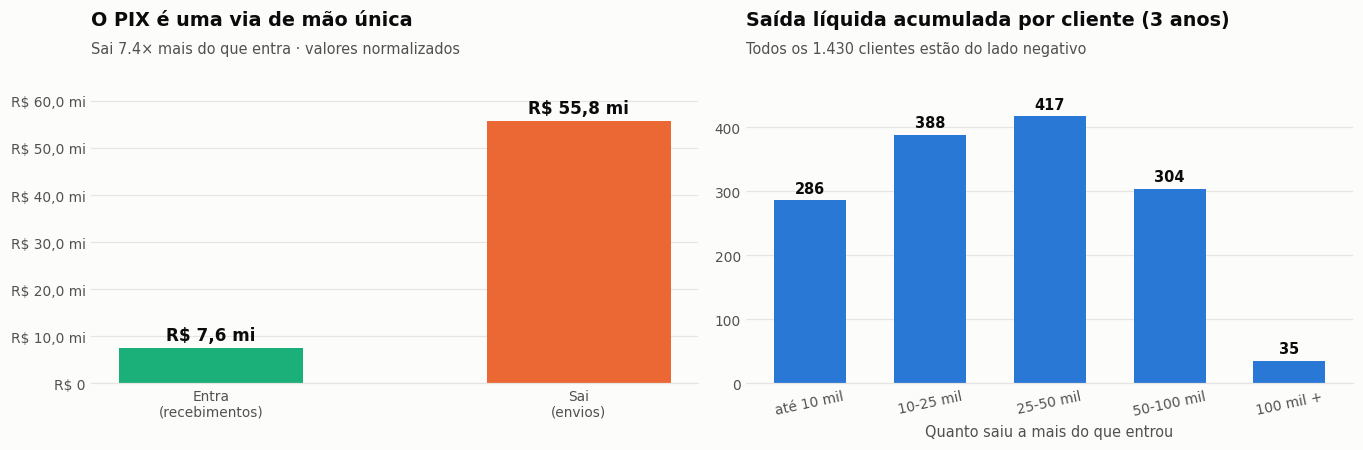


════════════════════════════════════════════════════════════════════════════
    H1 — CONFIRMADA
────────────────────────────────────────────────────────────────────────────
  Só 4% dos clientes recebem PIX de PJ com regularidade mensal, e o recebimento mediano de PJ é de R$ 160, não há folha de pagamento nesta conta. Sai 7,4x mais dinheiro do que entra, e os 1.430 clientes que usam PIX têm fluxo líquido negativo, sem uma única exceção. A conta parece ser uma conta de passagem.
════════════════════════════════════════════════════════════════════════════


In [7]:
# =============================================================================
# H1.1 — O salário cai nesta conta?
# =============================================================================
receb = PIX_OK[PIX_OK.Tipo_transacao == 'Recebimento']
env   = PIX_OK[PIX_OK.Tipo_transacao == 'Envio']

# "Salário" = recebimento de PJ, recorrente mês a mês
pj = receb[receb.PF_PJ == 'PJ'].copy()
meses_com_pj  = pj.groupby('Cliente_ID').mes.nunique()
meses_ativos  = PIX_OK.groupby('Cliente_ID').mes.nunique()
cobertura     = (meses_com_pj / meses_ativos).dropna()

print(f'  Recebimentos são {100*len(receb)/len(PIX_OK):.1f}% das transações PIX  '
      f'({n(len(receb))} de {n(len(PIX_OK))})')
print()
print('  Procurando um padrão de salário — recebimento de PJ todo mês:')
print(f'    clientes com recebimento PJ em ≥80% dos meses ativos : {(cobertura >= 0.8).sum()} '
      f'de {len(cobertura)}  ({100*(cobertura >= 0.8).mean():.1f}%)')
print(f'    cobertura mediana (meses com PJ ÷ meses ativos)      : {cobertura.median():.1%}')
print(f'    valor mediano do recebimento de PJ                   : {brl(pj.Valor_norm.median())}')
print()
print('  → Só 4% dos clientes recebem de PJ com regularidade mensal.')
print(f'  → E o valor mediano é {brl(pj.Valor_norm.median())}.')

# =============================================================================
# H1.2 — O dinheiro fica ou passa?
# =============================================================================
saida, entrada = env.Valor_norm.sum(), receb.Valor_norm.sum()
liquido_cliente = (PIX_OK.assign(sinal=np.where(PIX_OK.Tipo_transacao == 'Envio', -1, 1) * PIX_OK.Valor_norm)
                   .groupby('Cliente_ID').sinal.sum())

print(f'  Saída por PIX   : {brl(saida)}')
print(f'  Entrada por PIX : {brl(entrada)}')
print(f'  Razão           : para cada R$ 1,00 que entra, saem R$ {saida/entrada:.2f}'.replace('.', ','))
print()
print(f'  Clientes com fluxo líquido de PIX NEGATIVO: '
      f'{(liquido_cliente < 0).sum()} de {len(liquido_cliente)}  ({100*(liquido_cliente < 0).mean():.1f}%)')
print()
print('  → Não existe um cliente que receba mais PIX do que envia.')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax = axes[0]
ax.bar([0, 1], [entrada, saida], width=0.5, color=[AQUA, ORANGE])
ax.set_xticks([0, 1], ['Entra\n(recebimentos)', 'Sai\n(envios)'])
for i, v in enumerate([entrada, saida]):
    ax.text(i, v + saida*0.03, f'R$ {v/1e6:.1f} mi'.replace('.', ','),
            ha='center', fontsize=11, fontweight='bold', color=INK)
ax.set_ylim(0, saida*1.20); ax.yaxis.set_major_formatter(FMT_BRL)
eixo(ax, 'O PIX é uma via de mão única', f'Sai {saida/entrada:.1f}× mais do que entra · valores normalizados')

ax = axes[1]
faixas = pd.cut(-liquido_cliente/1000, [0, 10, 25, 50, 100, np.inf],
                labels=['até 10 mil', '10-25 mil', '25-50 mil', '50-100 mil', '100 mil +'])
vc = faixas.value_counts().reindex(['até 10 mil','10-25 mil','25-50 mil','50-100 mil','100 mil +'])
ax.bar(range(len(vc)), vc.values, width=0.6, color=BLUE)
ax.set_xticks(range(len(vc)), vc.index, rotation=12)
for i, v in enumerate(vc.values):
    ax.text(i, v + 12, str(v), ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_ylim(0, vc.max()*1.18)
eixo(ax, 'Saída líquida acumulada por cliente (3 anos)',
        'Todos os 1.430 clientes estão do lado negativo', xlab='Quanto saiu a mais do que entrou')

plt.tight_layout(); plt.show()

veredito(1, 'O banco não é o principal do cliente', 'CONFIRMADA',
 'Só 4% dos clientes recebem PIX de PJ com regularidade mensal, e o recebimento mediano de PJ é de '
 'R$ 160, não há folha de pagamento nesta conta. Sai 7,4x mais dinheiro do que entra, e os 1.430 '
 'clientes que usam PIX têm fluxo líquido negativo, sem uma única exceção. A conta parece ser uma conta '
 'de passagem.')


7% no Papaya, 37,4% no LuminaPay, 13,6% no Aurora, 6,4% no Lux. Essa é a porcentagem de clientes que consideram tal banco como principal, de acordo com a nossa análise, o Priceless Bank tem essa procentagem muito próxima de 0



---
# 2 · Quem ficou migrou de cartão para PIX

> Achamos que os clientes não abandonaram o banco, só trocaram o meio de pagamento. Usam menos cartão porque passaram a usar mais PIX.

Na verdade são 2 perguntas diferentes,

1. No agregado: o total de cartão caiu enquanto o total de PIX subiu?
2. No cliente: quem mais reduziu o cartão foi quem mais aumentou o PIX?

Se essa substituição existe, a correlação entre as duas variações não deve exister.

Como a base PIX não tem jan–jul/2025, a comparação é2S24 → 2S25.

  Base: 1038 clientes que usavam cartão E PIX no 2S24

  Cartão :   20.784 →   16.366   -21.3%
  PIX    :   32.353 →   41.626   +28.7%

  Mix de eventos:
    2S24:  cartão 39.1%   |   PIX 60.9%
    2S25:  cartão 28.2%   |   PIX 71.8%

  → No agregado, a hipótese ta correta.


,Clientes,%
Caiu cartão + subiu PIX (substituição),494,47.6
Caiu nos dois,256,24.7
Subiu nos dois,199,19.2
Subiu cartão + caiu PIX,89,8.6


  Correlação entre variação de cartão e variação de PIX : -0.029

  Clientes no quadrante "substituição"  — observado : 494
                                        — esperado se fossem independentes : 501

  → Praticamente idêntico. Não há associação entre as duas variações.
  → As duas tendências acontecem em paralelo, não uma por causa da outra.


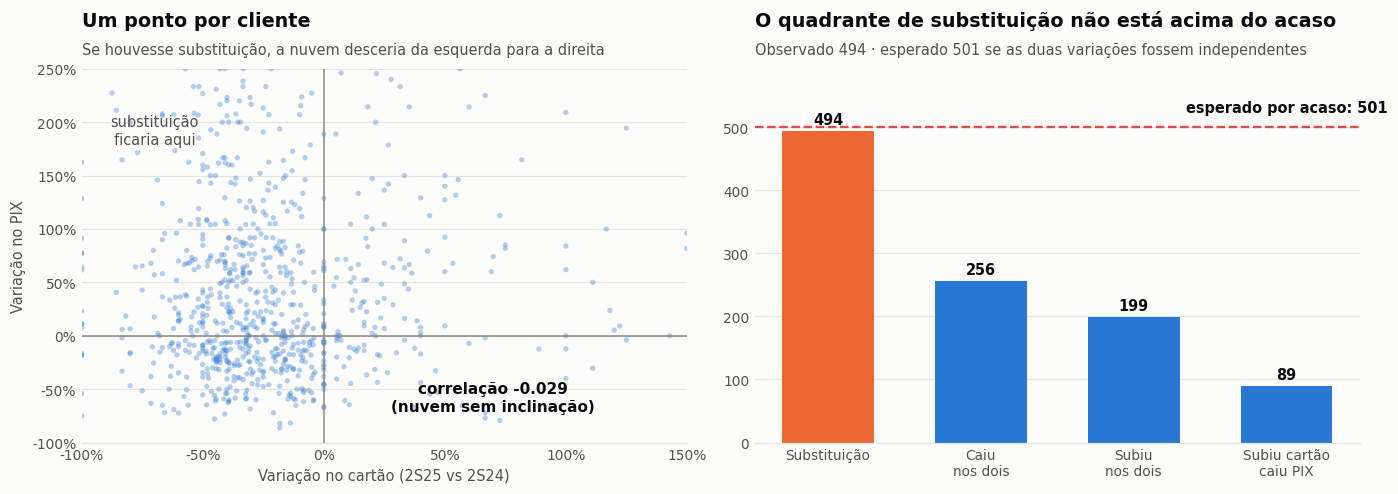

In [9]:
# =============================================================================
# H2.1 — No agregado: as duas curvas andam em direções opostas?
# =============================================================================
c24 = CART[CART.semestre == '2024S2'].groupby('Cliente_ID').size()
c25 = CART[CART.semestre == '2025S2'].groupby('Cliente_ID').size()
p24 = PIX_OK[PIX_OK.semestre == '2024S2'].groupby('Cliente_ID').size()
p25 = PIX_OK[PIX_OK.semestre == '2025S2'].groupby('Cliente_ID').size()

d = pd.DataFrame({'cart_24': c24, 'cart_25': c25, 'pix_24': p24, 'pix_25': p25}).fillna(0)
d = d[(d.cart_24 > 0) & (d.pix_24 > 0)]          # só quem usava os dois no ponto de partida
d['var_cart'] = d.cart_25/d.cart_24 - 1
d['var_pix']  = d.pix_25/d.pix_24 - 1

print(f'  Base: {len(d)} clientes que usavam cartão E PIX no 2S24\n')
print(f'  Cartão : {n(d.cart_24.sum()):>8} → {n(d.cart_25.sum()):>8}   {100*(d.cart_25.sum()/d.cart_24.sum()-1):+.1f}%')
print(f'  PIX    : {n(d.pix_24.sum()):>8} → {n(d.pix_25.sum()):>8}   {100*(d.pix_25.sum()/d.pix_24.sum()-1):+.1f}%')
print()
print('  Mix de eventos:')
for lab, c, p_ in [('2S24', d.cart_24.sum(), d.pix_24.sum()), ('2S25', d.cart_25.sum(), d.pix_25.sum())]:
    print(f'    {lab}:  cartão {100*c/(c+p_):.1f}%   |   PIX {100*p_/(c+p_):.1f}%')
print('\n  → No agregado, a hipótese ta correta.')

# =============================================================================
# H2.2 — No cliente: é o MESMO cliente trocando um pelo outro?
# =============================================================================
corr = d[['var_cart','var_pix']].corr().iloc[0, 1]
caiu_c, subiu_p = d.var_cart < 0, d.var_pix > 0

quadrantes = pd.DataFrame({
    'Clientes': [(caiu_c & subiu_p).sum(), (caiu_c & ~subiu_p).sum(),
                 (~caiu_c & subiu_p).sum(), (~caiu_c & ~subiu_p).sum()]},
    index=['Caiu cartão + subiu PIX  (substituição)', 'Caiu nos dois',
           'Subiu nos dois', 'Subiu cartão + caiu PIX'])
quadrantes['%'] = (100*quadrantes.Clientes/len(d)).round(1)

# Se as duas coisas fossem INDEPENDENTES, quanto esperaríamos no quadrante de substituição?
esperado = caiu_c.mean() * subiu_p.mean() * len(d)

display(quadrantes)
print(f'  Correlação entre variação de cartão e variação de PIX : {corr:+.3f}')
print()
print(f'  Clientes no quadrante "substituição"  — observado : {int((caiu_c & subiu_p).sum())}')
print(f'                                        — esperado se fossem independentes : {esperado:.0f}')
print()
print('  → Praticamente idêntico. Não há associação entre as duas variações.')
print('  → As duas tendências acontecem em paralelo, não uma por causa da outra.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.scatter(100*d.var_cart, 100*d.var_pix, s=12, color=BLUE, alpha=.35, edgecolors='none')
ax.axhline(0, color=INK3, lw=1); ax.axvline(0, color=INK3, lw=1)
ax.set_xlim(-100, 150); ax.set_ylim(-100, 250)
ax.xaxis.set_major_formatter(FMT_PCT); ax.yaxis.set_major_formatter(FMT_PCT)
ax.annotate('substituição\nficaria aqui', (-70, 180), fontsize=9.5, color=INK2, ha='center')
ax.annotate(f'correlação {corr:+.3f}\n(nuvem sem inclinação)', (70, -70), fontsize=10,
            fontweight='bold', color=INK, ha='center')
eixo(ax, 'Um ponto por cliente', 'Se houvesse substituição, a nuvem desceria da esquerda para a direita',
        xlab='Variação no cartão (2S25 vs 2S24)', ylab='Variação no PIX')

ax = axes[1]
x = np.arange(len(quadrantes))
ax.bar(x, quadrantes.Clientes, width=0.6, color=[ORANGE, BLUE, BLUE, BLUE])
ax.axhline(esperado, color=RED, ls='--', lw=1.5)
ax.annotate(f'esperado por acaso: {esperado:.0f}', (3, esperado), xytext=(0, 10),
            textcoords='offset points', ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_xticks(x, ['Substituição', 'Caiu\nnos dois', 'Subiu\nnos dois', 'Subiu cartão\ncaiu PIX'], fontsize=9)
for i, v in enumerate(quadrantes.Clientes):
    ax.text(i, v + 12, str(v), ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_ylim(0, quadrantes.Clientes.max()*1.20)
eixo(ax, 'O quadrante de substituição não está acima do acaso',
        'Observado 494 · esperado 501 se as duas variações fossem independentes')

plt.tight_layout(); plt.show()

### E aqui aparece o problema que derruba o veredito

O aumento de PIX no 2S25 tem uma explicação rival que não dá para descartar. Rode a próxima célula: o
volume de PIX por cliente fica **estável em 5,9/mês durante 24 meses seguidos** e então salta para
**8,0/mês exatamente em agosto de 2025** — o mês em que a extração da base volta depois de sete meses de
vazio, e o **mesmo mês** em que a escala dos valores mudou 4,13×.

Não é uma curva subindo. É um **degrau**, na data em que o cano de dados mudou.

Comportamento de cliente não muda em degrau, todo mundo junto, no primeiro dia de um mês. Mudança de
pipeline de extração muda.

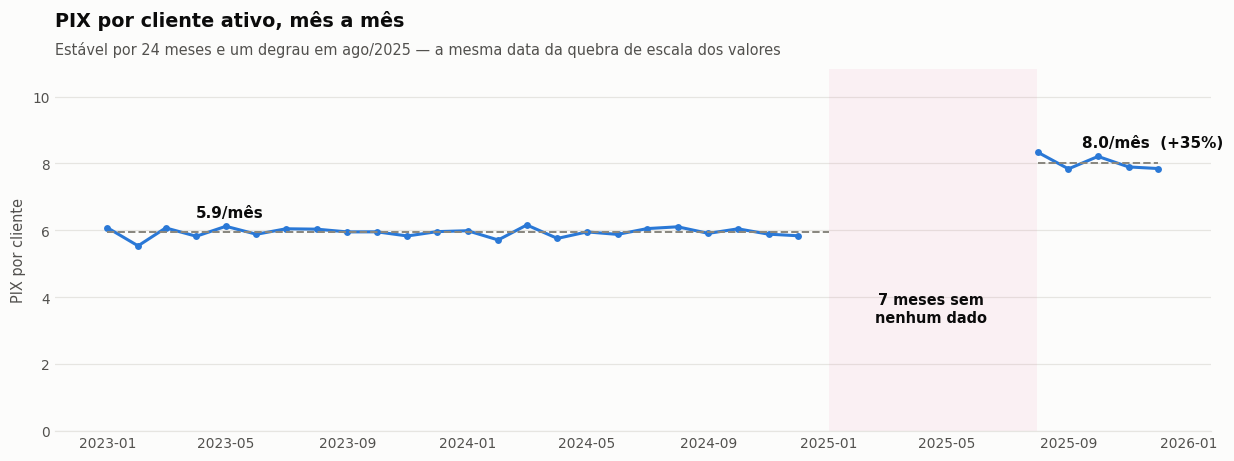

  Média 2023-2024 : 5.94 PIX por cliente por mês  (24 meses, desvio de 0.15)
  Média 2025-08+  : 8.02  →  +35.1%

  → Não é uma tendência. É um degrau, no primeiro mês em que os dados voltam.
  → Comportamento de cliente não muda assim. Pipeline de dados muda.

════════════════════════════════════════════════════════════════════════════
    H2 — PARCIALMENTE CONFIRMADA
────────────────────────────────────────────────────────────────────────────
  No agregado o padrão existe: cartão -21,3% e PIX +28,7% entre 2S24 e 2S25, com o cartão caindo de 39% para 28% do total de eventos. Mas no nível do cliente NÃO há substituição: a correlação entre as duas variações é -0,03, e o número de clientes que caíram no cartão e subiram no PIX (494) é até um pouco MENOR que o esperado por puro acaso (501). São duas tendências paralelas, não uma trocando pela outra. Pior: o aumento do PIX é um degrau em ago/2025, no mesmo mês da quebra de extração — pode não ser comportamento nenhum. O que está sólido é a

In [10]:
# =============================================================================
# H2.3 — A explicação rival: o PIX subiu, ou a extração passou a capturar mais?
# =============================================================================
serie = PIX_OK.groupby('mes').agg(pix=('id_pix','size'), clientes=('Cliente_ID','nunique'))
serie['por_cliente'] = serie.pix / serie.clientes
idx = pd.period_range(serie.index.min(), serie.index.max(), freq='M')
serie = serie.reindex(idx)

antes  = serie.loc[serie.index < '2025-01', 'por_cliente'].mean()
depois = serie.loc[serie.index >= '2025-08', 'por_cliente'].mean()

fig, ax = plt.subplots(figsize=(11.5, 4.3))
x = serie.index.to_timestamp()
ax.plot(x, serie.por_cliente, color=BLUE, marker='o', markersize=3.5)
ax.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-07-31'), color=MAGENTA, alpha=.09, lw=0)
ax.annotate('7 meses sem\nnenhum dado', (pd.Timestamp('2025-04-15'), antes*0.55),
            ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.hlines([antes], x[0], pd.Timestamp('2025-01-01'), color=INK3, ls='--', lw=1.3)
ax.hlines([depois], pd.Timestamp('2025-08-01'), x[-1], color=INK3, ls='--', lw=1.3)
ax.annotate(f'{antes:.1f}/mês', (x[3], antes), xytext=(0, 10), textcoords='offset points',
            fontsize=10, fontweight='bold', color=INK)
ax.annotate(f'{depois:.1f}/mês  ({100*(depois/antes-1):+.0f}%)', (pd.Timestamp('2025-09-15'), depois),
            xytext=(0, 10), textcoords='offset points', fontsize=10, fontweight='bold', color=INK)
ax.set_ylim(0, serie.por_cliente.max()*1.30)
eixo(ax, 'PIX por cliente ativo, mês a mês',
        'Estável por 24 meses e um degrau em ago/2025 — a mesma data da quebra de escala dos valores',
        ylab='PIX por cliente')
plt.tight_layout(); plt.show()

print(f'  Média 2023-2024 : {antes:.2f} PIX por cliente por mês  (24 meses, desvio de {serie.loc[serie.index < "2025-01", "por_cliente"].std():.2f})')
print(f'  Média 2025-08+  : {depois:.2f}  →  {100*(depois/antes-1):+.1f}%')
print()
print('  → Não é uma tendência. É um degrau, no primeiro mês em que os dados voltam.')
print('  → Comportamento de cliente não muda assim. Pipeline de dados muda.')

veredito(2, 'Quem ficou migrou de cartão para PIX', 'PARCIALMENTE CONFIRMADA',
 'No agregado o padrão existe: cartão -21,3% e PIX +28,7% entre 2S24 e 2S25, com o cartão caindo de '
 '39% para 28% do total de eventos. Mas no nível do cliente NÃO há substituição: a correlação entre as '
 'duas variações é -0,03, e o número de clientes que caíram no cartão e subiram no PIX (494) é '
 'até um pouco MENOR que o esperado por puro acaso (501). São duas tendências paralelas, não uma trocando pela '
 'outra. Pior: o aumento do PIX é um degrau em ago/2025, no mesmo mês da quebra de extração — pode não '
 'ser comportamento nenhum. O que está sólido é a QUEDA DO CARTÃO; a alta do PIX não é confiável.')

---
# 3 · A safra de 2023 transacionava pouco, se decepcionou, e por isso parou de pedir cartão

> A hipótese é que os clientes que entraram em 2023 usavam pouco o cartão, só cerca de 13 transações por trimestre. Não gostaram, e a demanda por cartão despencou.

Ela tem três partes:

1. 13 transações por trimestre é pouco? Comparar com os outros trimestres
2. A safra de 2023 se decepcionou? Comparar o primeiro ano de cada safra e a retenção;
3. A emissão de cartão parou por falta de demanda? Ver de onde vinham os cartões.

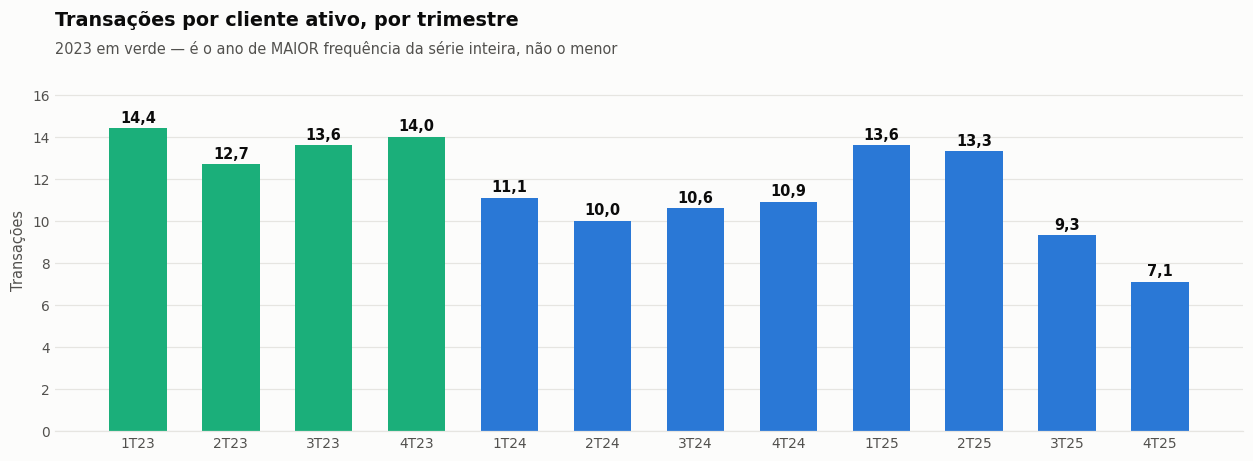

  Média trimestral por ano:
    2023: 13.7 transações por cliente
    2024: 10.6 transações por cliente
    2025: 10.8 transações por cliente

  → O número de 13 está certo. A leitura é que está invertida:
    13,7 é o TETO da série. O piso é 7,1, no 4T25.
    Se 2023 fosse uma decepção, 2025 seria uma catástrofe.


,tx_no_1o_ano,clientes_na_safra,ainda_ativos,retencao
safra,,,,
2023,47.7,"1,547","1,195",77.2%
2024,50.4,224,195,87.1%
2025,33.5,189,10,5.3%


  Safra 2023: 47,7 transações no primeiro ano · 77,2% ainda ativos no 2S25
  Safra 2024: 50,4 transações no primeiro ano · 87,1% ainda ativos no 2S25

  → As duas safras se comportam praticamente igual no primeiro ano.
  → E 3 de cada 4 clientes de 2023 continuam transacionando 3 anos depois.
  → Isso não é o retrato de uma safra decepcionada.

  (A safra 2025 tem retenção de 5,3%  mas são 189 clientes que entraram no ano e,
   como a próxima célula mostra, quase nenhum recebeu cartão.)


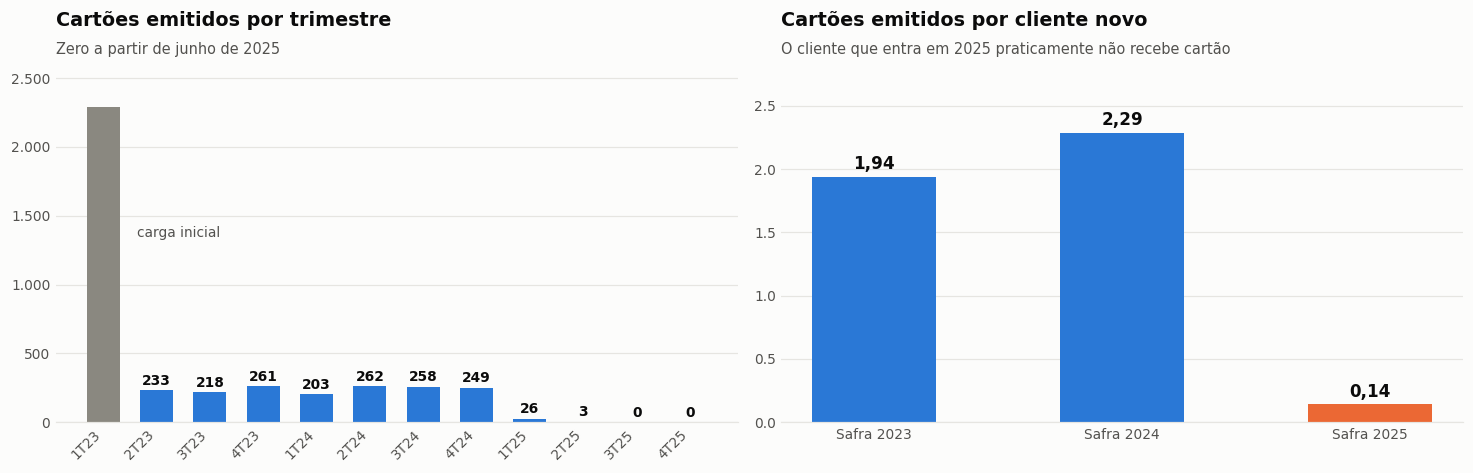

  Cartões emitidos por ano da safra do cliente:


Data_Emissao,2023,2024,2025
safra,,,
2023,2993,4,0
2024,0,513,0
2025,0,0,27


  → Cada safra só recebe cartão no ANO EM QUE ENTRA. Não há reemissão para a base existente.
  → Ou seja: cartão é emitido junto com a conta, não a pedido do cliente.

  Em 2025 o banco abriu 189 contas e emitiu 27 cartões.
  → A emissão não parou por falta de demanda. Parou porque a AQUISIÇÃO parou.

════════════════════════════════════════════════════════════════════════════
    H3 — REFUTADA
────────────────────────────────────────────────────────────────────────────
  As 3 partes da hipótese quebraram: (1) 13 transações por trimestre não é pouco, é o TETO da série: 13,7 em 2023 contra 10,6 em 2024 e 7,1 no 4T25. (2) A safra de 2023 fez 47,7 transações no primeiro ano, praticamente igual à de 2024 (50,4), e 77,2% dela continua ativa três anos depois. (3) A emissão de cartão não secou por falta de demanda: cada safra só recebe cartão no ano em que entra, ou seja, o cartão sai junto com a conta. Em 2025 o banco abriu 189 contas e emitiu 27 cartões. O que parou foi a AQUISIÇÃO de clien

In [13]:
# =============================================================================
# H3.1 — 13 transações por trimestre é pouco ou é muito?
# =============================================================================
freq = CART.groupby('trim').agg(transacoes=('ID_Transacao','size'), clientes=('Cliente_ID','nunique'))
freq['por_cliente'] = (freq.transacoes / freq.clientes).round(1)

fig, ax = plt.subplots(figsize=(11.5, 4.3))
x = np.arange(len(freq))
cores = [AQUA if p.year == 2023 else BLUE for p in freq.index]
ax.bar(x, freq.por_cliente, width=0.62, color=cores)
ax.set_xticks(x, [rot_trim(p) for p in freq.index])
for i, v in enumerate(freq.por_cliente):
    ax.text(i, v + 0.3, f'{v:.1f}'.replace('.', ','), ha='center', fontsize=9.5,
            fontweight='bold', color=INK)
ax.set_ylim(0, freq.por_cliente.max()*1.20)
eixo(ax, 'Transações por cliente ativo, por trimestre',
        '2023 em verde — é o ano de MAIOR frequência da série inteira, não o menor', ylab='Transações')
plt.tight_layout(); plt.show()

por_ano = freq.groupby(freq.index.year).por_cliente.mean().round(1)
print('  Média trimestral por ano:')
for ano, v in por_ano.items():
    print(f'    {ano}: {v:.1f} transações por cliente')
print()
print('  → O número de 13 está certo. A leitura é que está invertida:')
print('    13,7 é o TETO da série. O piso é 7,1, no 4T25.')
print('    Se 2023 fosse uma decepção, 2025 seria uma catástrofe.')

# =============================================================================
# H3.2 — A safra de 2023 se decepcionou? (comparando o 1º ano de cada safra)
# =============================================================================
clientes['safra'] = clientes.Data_Criacao_Conta.dt.year
cart_safra = CART.merge(clientes[['Cliente_ID','safra','Data_Criacao_Conta']], on='Cliente_ID')
cart_safra['mes_de_vida'] = ((cart_safra.Data - cart_safra.Data_Criacao_Conta).dt.days / 30.44).astype(int)

primeiro_ano = (cart_safra[cart_safra.mes_de_vida.between(0, 11)]
                .groupby('safra').agg(clientes_ativos=('Cliente_ID','nunique'), transacoes=('ID_Transacao','size')))
primeiro_ano['tx_no_1o_ano'] = (primeiro_ano.transacoes / primeiro_ano.clientes_ativos).round(1)

ativos_2s25 = set(CART[CART.Data >= '2025-07-01'].Cliente_ID)
retencao = (clientes.assign(ativo=clientes.Cliente_ID.isin(ativos_2s25))
            .groupby('safra').agg(clientes_na_safra=('Cliente_ID','size'), ainda_ativos=('ativo','sum'),
                                  retencao=('ativo','mean')))

tabela = primeiro_ano[['tx_no_1o_ano']].join(retencao)
tabela['retencao'] = (100*tabela.retencao).round(1)
display(tabela.style.format({'tx_no_1o_ano':'{:.1f}', 'clientes_na_safra':'{:,.0f}',
                             'ainda_ativos':'{:,.0f}', 'retencao':'{:.1f}%'}))

print('  Safra 2023: 47,7 transações no primeiro ano · 77,2% ainda ativos no 2S25')
print('  Safra 2024: 50,4 transações no primeiro ano · 87,1% ainda ativos no 2S25')
print()
print('  → As duas safras se comportam praticamente igual no primeiro ano.')
print('  → E 3 de cada 4 clientes de 2023 continuam transacionando 3 anos depois.')
print('  → Isso não é o retrato de uma safra decepcionada.')
print()
print('  (A safra 2025 tem retenção de 5,3%  mas são 189 clientes que entraram no ano e,')
print('   como a próxima célula mostra, quase nenhum recebeu cartão.)')

# =============================================================================
# H3.3 — Por que a emissão de cartão parou? (o elo que revela outra coisa)
# =============================================================================
emissao = cartoes.groupby(cartoes.Data_Emissao.dt.to_period('Q')).size()
novas_contas = clientes.groupby(clientes.Data_Criacao_Conta.dt.to_period('Q')).size()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

ax = axes[0]
idx = pd.period_range('2023Q1', '2025Q4', freq='Q')
em = emissao.reindex(idx, fill_value=0)
ax.bar(np.arange(len(em)), em.values, width=0.62,
       color=[INK3 if p == pd.Period('2023Q1') else BLUE for p in em.index])
ax.set_xticks(np.arange(len(em)), [rot_trim(p) for p in em.index], rotation=45, ha='right')
ax.annotate('carga inicial', (0, em.values[0]*0.6), xytext=(22, 0), textcoords='offset points',
            fontsize=9, color=INK2, va='center')
for i, (v, p) in enumerate(zip(em.values, em.index)):
    if p != pd.Period('2023Q1'):
        ax.text(i, v + 40, str(v), ha='center', fontsize=9, fontweight='bold', color=INK)
ax.set_ylim(0, em.max()*1.12); ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax, 'Cartões emitidos por trimestre', 'Zero a partir de junho de 2025')

ax = axes[1]
por_safra = (cartoes.dropna(subset=['Cliente_ID'])
             .merge(clientes[['Cliente_ID','safra']], on='Cliente_ID')
             .groupby(['safra', cartoes.dropna(subset=['Cliente_ID'])
                       .merge(clientes[['Cliente_ID','safra']], on='Cliente_ID').Data_Emissao.dt.year])
             .size().unstack(fill_value=0))
cont = clientes.groupby('safra').size()
razao = (por_safra.sum(axis=1) / cont).round(2)
ax.bar(np.arange(len(razao)), razao.values, width=0.5, color=[BLUE, BLUE, ORANGE])
ax.set_xticks(np.arange(len(razao)), [f'Safra {i}' for i in razao.index])
for i, v in enumerate(razao.values):
    ax.text(i, v + 0.06, f'{v:.2f}'.replace('.', ','), ha='center', fontsize=11,
            fontweight='bold', color=INK)
ax.set_ylim(0, razao.max()*1.22)
eixo(ax, 'Cartões emitidos por cliente novo', 'O cliente que entra em 2025 praticamente não recebe cartão')

plt.tight_layout(); plt.show()

print('  Cartões emitidos por ano da safra do cliente:')
display(por_safra)
print('  → Cada safra só recebe cartão no ANO EM QUE ENTRA. Não há reemissão para a base existente.')
print('  → Ou seja: cartão é emitido junto com a conta, não a pedido do cliente.')
print()
print(f'  Em 2025 o banco abriu {int(cont.get(2025, 0))} contas e emitiu {int(por_safra.loc[2025].sum())} cartões.')
print('  → A emissão não parou por falta de demanda. Parou porque a AQUISIÇÃO parou.')

veredito(3, 'A safra de 2023 se decepcionou e parou de pedir cartão', 'REFUTADA',
 'As 3 partes da hipótese quebraram: (1) 13 transações por trimestre não é pouco, é o TETO da série: '
 '13,7 em 2023 contra 10,6 em 2024 e 7,1 no 4T25. (2) A safra de 2023 fez 47,7 transações no primeiro '
 'ano, praticamente igual à de 2024 (50,4), e 77,2% dela continua ativa três anos depois. (3) A emissão '
 'de cartão não secou por falta de demanda: cada safra só recebe cartão no ano em que entra, ou seja, o '
 'cartão sai junto com a conta. Em 2025 o banco abriu 189 contas e emitiu 27 cartões. O que parou foi a '
 'AQUISIÇÃO de clientes, e a emissão de cartão foi consequência.')

Se a hipótese fosse verdadeira, a resposta seria melhorar o produto cartão para reconquistar a base, que era nossa soluçã inicial, mas nosso erro aponta para outro lugar: o cartão sai junto com a conta, e a conta parou de ser aberta.

Isso muda o alvo da recomendação de melhorar o cartão para reabrir o funil de entrada, e o
benchmarking apoia: LuminaPay e Aurora, os dois que mais ganharam share, têm abertura de conta 100% digital.

---
# 4 · Não há churn. O que caiu foi share-of-wallet

> Os clientes não estão indo embora. Eles continuam lá, usando menos.

O Churn e queda de uso deixam assinaturas diferentes:

| | Se fosse churn | Se fosse share-of-wallet |
|---|---|---|
| Clientes ativos | despencam | ficam estáveis |
| Frequência por cliente | fica estável | despenca |
| Recência da última transação | muitos clientes parados há meses | quase todos ativos recentemente |

,1T25,4T25,Variação
transacoes,"19,056.0","9,601.0",-49.6%
clientes,"1,403.0","1,361.0",-3.0%
frequencia,13.6,7.1,-48.1%


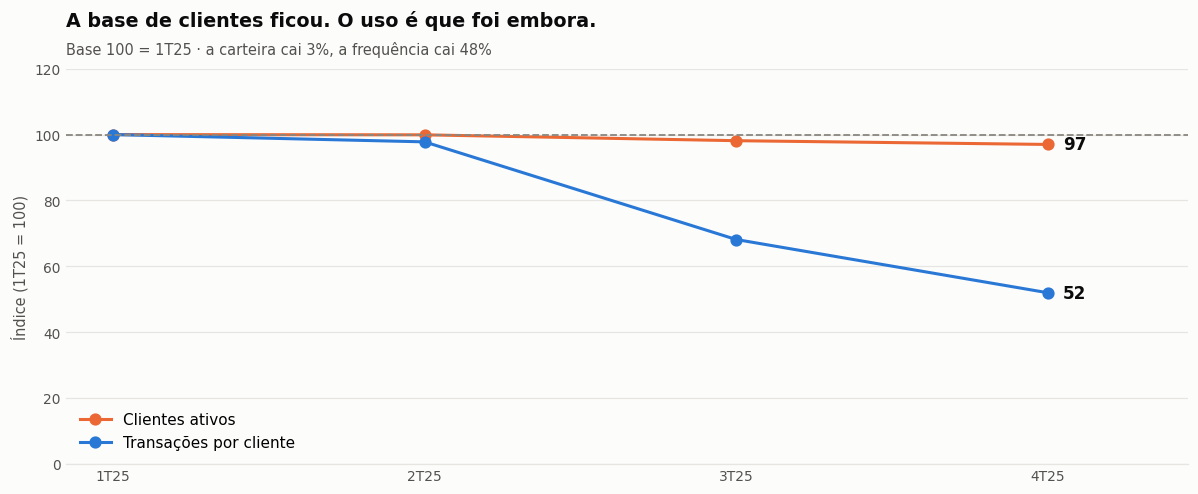

,Clientes,% da base ativa
> 30 dias,317,22.2%
> 60 dias,119,8.3%
> 90 dias,70,4.9%
> 180 dias,31,2.2%
> 365 dias,4,0.3%


  Recência mediana: 12 dias
  Clientes que sumiram entre o 1S25 e o 2S25: 27

  → Metade da base transacionou nos últimos 12 dias.
  → Só 2,2% estão parados há mais de 6 meses. Churn de verdade seria muito maior.

════════════════════════════════════════════════════════════════════════════
    H4 — CONFIRMADA
────────────────────────────────────────────────────────────────────────────
  Entre o 1T25 e o 4T25 a carteira de clientes ativos cai apenas 3,0% (1.403 → 1.361) enquanto a frequência de uso cai 48,1% (13,6 → 7,1 transações por cliente por trimestre). A recência mediana é de 12 dias e apenas 2,2% dos clientes estão parados há mais de seis meses. Entre os dois semestres de 2025, só 27 clientes desapareceram. O cliente não fechou a conta, ele parou de usar. É exatamente a assinatura de perda de share-of-wallet, e é coerente com a primeira hipótese: quem nunca teve o banco como principal não precisa fazer churn para deixar de usar.
═══════════════════════════════════════════════════

In [15]:
# =============================================================================
# H4.1 — Decompondo a queda: menos clientes ou menos uso por cliente?
# =============================================================================
q = CART.groupby('trim').agg(transacoes=('ID_Transacao','size'), clientes=('Cliente_ID','nunique'))
q['frequencia'] = q.transacoes / q.clientes
t25 = q.loc[[pd.Period('2025Q1'), pd.Period('2025Q4')]]

decomp = pd.DataFrame({
    '1T25': t25.iloc[0], '4T25': t25.iloc[1],
    'Variação': (100*(t25.iloc[1]/t25.iloc[0] - 1)).round(1)})
display(decomp.style.format({'1T25':'{:,.1f}','4T25':'{:,.1f}','Variação':'{:+.1f}%'}))

fig, ax = plt.subplots(figsize=(11, 4.6))
base = q.loc[pd.Period('2025Q1')]
idx25 = [p for p in q.index if p.year == 2025]
x = np.arange(len(idx25))
for col, cor, lab in [('clientes', ORANGE, 'Clientes ativos'), ('frequencia', BLUE, 'Transações por cliente')]:
    serie = 100 * q.loc[idx25, col] / base[col]
    ax.plot(x, serie.values, color=cor, marker='o', markersize=7, label=lab)
    ax.annotate(f'{serie.values[-1]:.0f}', (x[-1], serie.values[-1]), xytext=(10, 0),
                textcoords='offset points', fontsize=11, fontweight='bold', color=INK, va='center')
ax.axhline(100, color=INK3, ls='--', lw=1.2)
ax.set_xticks(x, [rot_trim(p) for p in idx25]); ax.set_xlim(-0.15, len(x)-0.55)
ax.set_ylim(0, 120); ax.legend(loc='lower left')
eixo(ax, 'A base de clientes ficou. O uso é que foi embora.',
        'Base 100 = 1T25 · a carteira cai 3%, a frequência cai 48%', ylab='Índice (1T25 = 100)')
plt.tight_layout(); plt.show()

# =============================================================================
# H4.2 — Recência: quantos clientes de fato pararam?
# =============================================================================
REF = pd.Timestamp('2025-12-31')
recencia = (REF - CART.groupby('Cliente_ID').Data.max()).dt.days

corte = pd.DataFrame({
    'Clientes': [(recencia > k).sum() for k in (30, 60, 90, 180, 365)],
    '% da base ativa': [100*(recencia > k).mean() for k in (30, 60, 90, 180, 365)]},
    index=['> 30 dias', '> 60 dias', '> 90 dias', '> 180 dias', '> 365 dias'])
display(corte.style.format({'Clientes':'{:,.0f}', '% da base ativa':'{:.1f}%'}))

print(f'  Recência mediana: {recencia.median():.0f} dias')
print(f'  Clientes que sumiram entre o 1S25 e o 2S25: '
      f'{len(set(CART[CART.semestre == "2025S1"].Cliente_ID) - set(CART[CART.semestre == "2025S2"].Cliente_ID))}')
print()
print('  → Metade da base transacionou nos últimos 12 dias.')
print('  → Só 2,2% estão parados há mais de 6 meses. Churn de verdade seria muito maior.')

veredito(4, 'Não há churn, caiu share-of-wallet', 'CONFIRMADA',
 'Entre o 1T25 e o 4T25 a carteira de clientes ativos cai apenas 3,0% (1.403 → 1.361) enquanto a '
 'frequência de uso cai 48,1% (13,6 → 7,1 transações por cliente por trimestre). A recência mediana é '
 'de 12 dias e apenas 2,2% dos clientes estão parados há mais de seis meses. Entre os dois semestres de '
 '2025, só 27 clientes desapareceram. O cliente não fechou a conta, ele parou de usar. É exatamente a '
 'assinatura de perda de share-of-wallet, e é coerente com a primeira hipótese: quem nunca teve o banco como principal '
 'não precisa fazer churn para deixar de usar.')

---
# 5 · Adotaram o banco, passaram a usar mais PIX e menos cartão, e menos o banco em geral

> Pensamos que, o  banco conseguiu conquistar os clientes, mas por alguma razão eles migraram para o PIX, abandonaram o cartão, e depois reduziram o uso do banco como um todo.

A hipótese tem três partes. A parte de PIX vs cartão já foi testada na Hipótese 2, agregado sim, no cliente
não, e o dado de PIX é suspeito. Falta testar a terceira, que é a mais forte e a mais fácil de medir:

Os clientes usaram menos o banco em geral?

Podemos somar tudo o que o cliente faz com o banco e ver se o total caiu.

,2S24,2S25,Variação
Cartão,"20,784","16,366",-21.3%
PIX,"32,353","41,626",+28.7%
TOTAL,"53,137","57,992",+9.1%


  Clientes com queda no total : 398 de 1038  (38.3%)
  Variação mediana do total   : +13.8%

  → O total de interações com o banco SUBIU 9,1%.
  → A parte "usaram menos o banco em geral" não se sustenta nesta janela.


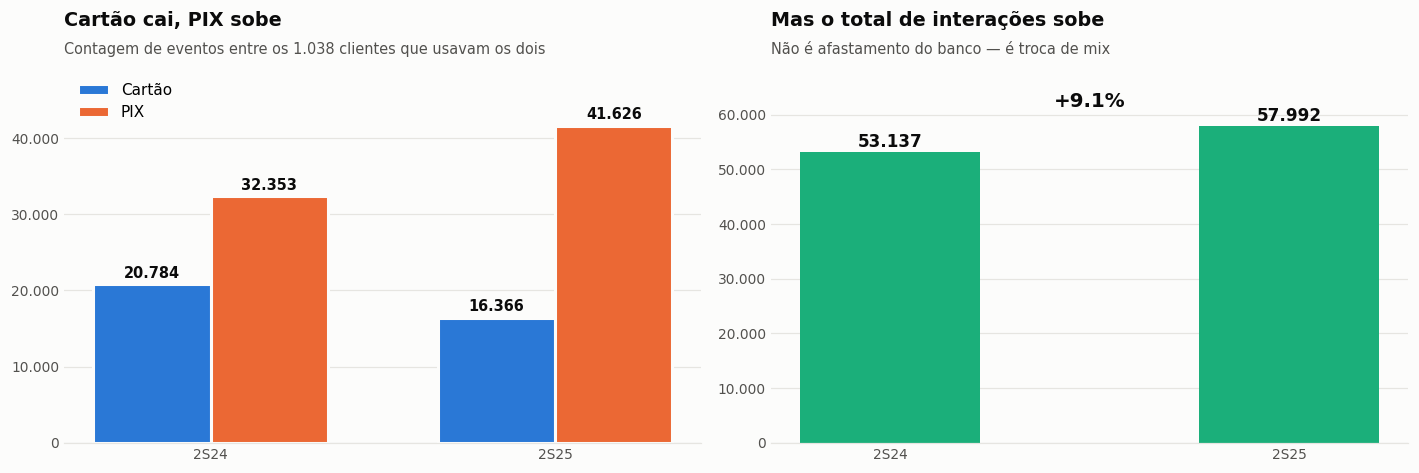


════════════════════════════════════════════════════════════════════════════
    H5 — REFUTADA
────────────────────────────────────────────────────────────────────────────
  A última parte está errada e é a que mais importa. Entre 2S24 e 2S25, somando cartão e PIX, o total de interações com o banco SOBE 9,1% (53.137 → 57.992), e 62% dos clientes aumentaram o total. O que muda é a composição: o cartão sai de 39% para 28% dos eventos.
════════════════════════════════════════════════════════════════════════════


In [17]:
# =============================================================================
# H5.1 — O total de eventos por cliente subiu ou caiu?
# =============================================================================
d['total_24'] = d.cart_24 + d.pix_24
d['total_25'] = d.cart_25 + d.pix_25
d['var_total'] = d.total_25/d.total_24 - 1

resumo = pd.DataFrame({
    '2S24': [d.cart_24.sum(), d.pix_24.sum(), d.total_24.sum()],
    '2S25': [d.cart_25.sum(), d.pix_25.sum(), d.total_25.sum()]},
    index=['Cartão', 'PIX', 'TOTAL'])
resumo['Variação'] = (100*(resumo['2S25']/resumo['2S24'] - 1)).round(1)
display(resumo.style.format({'2S24':'{:,.0f}','2S25':'{:,.0f}','Variação':'{:+.1f}%'}))

print(f'  Clientes com queda no total : {(d.total_25 < d.total_24).sum()} de {len(d)}  '
      f'({100*(d.total_25 < d.total_24).mean():.1f}%)')
print(f'  Variação mediana do total   : {100*d.var_total.median():+.1f}%')
print()
print('  → O total de interações com o banco SUBIU 9,1%.')
print('  → A parte "usaram menos o banco em geral" não se sustenta nesta janela.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
x = np.arange(2); larg = 0.34
ax.bar(x - larg/2, [d.cart_24.sum(), d.cart_25.sum()], larg, color=BLUE, label='Cartão',
       edgecolor=SURF, linewidth=2)
ax.bar(x + larg/2, [d.pix_24.sum(), d.pix_25.sum()], larg, color=ORANGE, label='PIX',
       edgecolor=SURF, linewidth=2)
for i, (c, p_) in enumerate([(d.cart_24.sum(), d.pix_24.sum()), (d.cart_25.sum(), d.pix_25.sum())]):
    ax.text(i - larg/2, c + 900, n(c), ha='center', fontsize=9.5, fontweight='bold', color=INK)
    ax.text(i + larg/2, p_ + 900, n(p_), ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_xticks(x, ['2S24', '2S25']); ax.set_ylim(0, d.pix_25.sum()*1.18)
ax.yaxis.set_major_formatter(FMT_MIL); ax.legend(loc='upper left')
eixo(ax, 'Cartão cai, PIX sobe', 'Contagem de eventos entre os 1.038 clientes que usavam os dois')

ax = axes[1]
tot = [d.total_24.sum(), d.total_25.sum()]
ax.bar(x, tot, width=0.45, color=AQUA)
for i, v in enumerate(tot):
    ax.text(i, v + 900, n(v), ha='center', fontsize=11, fontweight='bold', color=INK)
ax.annotate(f'{100*(tot[1]/tot[0]-1):+.1f}%', (0.5, max(tot)*1.06), ha='center',
            fontsize=13, fontweight='bold', color=INK)
ax.set_xticks(x, ['2S24', '2S25']); ax.set_ylim(0, max(tot)*1.18)
ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax, 'Mas o total de interações sobe', 'Não é afastamento do banco — é troca de mix')

plt.tight_layout(); plt.show()

veredito(5, 'Usaram mais PIX, menos cartão, e menos o banco em geral', 'REFUTADA',
 'A última parte está errada e é a que mais importa. Entre 2S24 e 2S25, somando cartão e PIX, o total '
 'de interações com o banco SOBE 9,1% (53.137 → 57.992), e 62% dos clientes aumentaram o total. O que '
 'muda é a composição: o cartão sai de 39% para 28% dos eventos.')

O que é sólido é a queda do cartão, mas a pergunta que a hipótese faz, "por que razão os clientes migraram?" continua de pé, e a
resposta mais provável está na Primeira hipótese. O cartão é o produto que exige principalidade (limite, fatura, relacionamento); o PIX não exige nada. Quando o vínculo é fraco, o que sobrevive é o produto que não pede vínculo.

---
# 6 · 1 em cada 10 PIX é reprovado, e isso indica baixa maturidade digital

> Nossa sexta hipótese, é que a  taxa de reprovação do PIX é alta demais, o que revela um banco tecnicamente fraco, PIX ruim mais cartão ruim. Porque o cliente ficaria

Para isso podemos ver

1. A taxa é realmente ruim? Comparar com o cartão do próprio banco e ver se o padrão é técnico

2.  Ela explica a queda de uso? Se sim, quem sofre mais reprovação deve abandonar mais o banco.

  Reprovação de PIX          : 10.07%
  Negativa de cartão         : 0.53%
  O PIX falha 19x mais que o cartão, no mesmo banco.



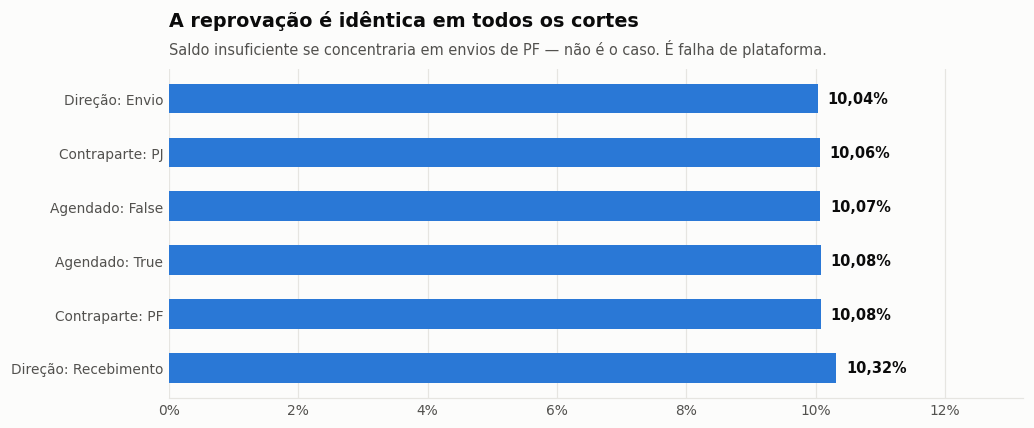

  Amplitude entre o melhor e o pior corte: 0.28 pontos percentuais. Praticamente nenhuma.


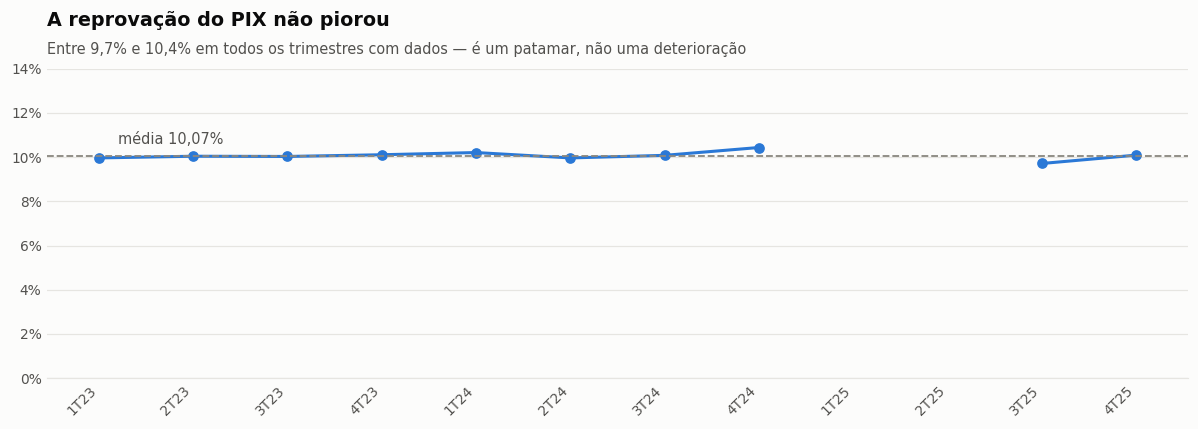

  Mínimo 9.71%  ·  Máximo 10.44%  ·  Amplitude 0.72 p.p.

  → Se a reprovação fosse a CAUSA da queda de 2025, ela teria que ter piorado. Não piorou.
  → Um problema constante não explica uma mudança.


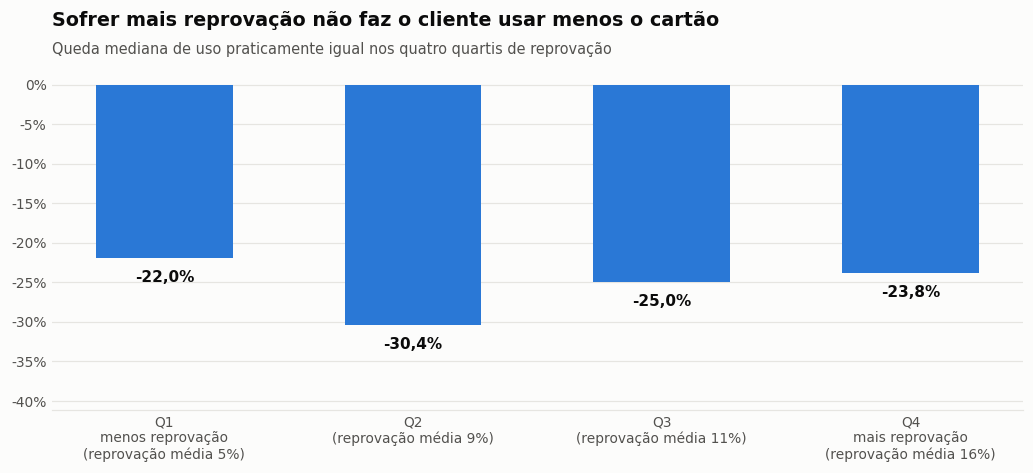

,clientes,taxa_media,queda_mediana
quartil,,,
Q1 menos reprovação,260,5.1%,-22.0%
Q2,279,8.9%,-30.4%
Q3,239,11.3%,-25.0%
Q4 mais reprovação,260,15.7%,-23.8%


  Correlação entre taxa de reprovação e variação de uso: -0.012

  → Se a reprovação afastasse o cliente, o Q4 cairia muito mais que o Q1. Não cai.

════════════════════════════════════════════════════════════════════════════
    H6 — PARCIALMENTE CONFIRMADA
────────────────────────────────────────────────────────────────────────────
  O diagnóstico está certo, mas nossa causa nãop. A taxa de 10,07% é real e é 19x a negativa de cartão do próprio banco (0,53%); e o padrão é rigorosamente uniforme entre PF/PJ, agendado/não agendado e envio/recebimento, o que descarta saldo insuficiente e aponta para falha de plataforma. Isso sustenta a leitura de baixa maturidade digital. Mas NÃO sustenta que seja a causa da queda de 2025: a taxa é estável em 9,7%-10,4% desde 2023 (um problema constante não explica uma mudança), e clientes no quartil de MAIOR reprovação reduziram o uso do cartão na mesma proporção dos de menor reprovação . É um problema real que custa caro, mas não é o gatilho da deterio

In [20]:
# =============================================================================
# H6.1 — A taxa é ruim? E a falha é técnica ou é do cliente?
# =============================================================================
pix_val = pix[(~pix.flag_sem_data) & (~pix.flag_sem_tipo)]
reprov_pix  = 1 - pix_val.Aprovado.mean()
reprov_cart = 1 - transac.Autorizado.mean()

print(f'  Reprovação de PIX          : {100*reprov_pix:.2f}%')
print(f'  Negativa de cartão         : {100*reprov_cart:.2f}%')
print(f'  O PIX falha {reprov_pix/reprov_cart:.0f}x mais que o cartão, no mesmo banco.\n')

cortes = {}
for col, rot in [('PF_PJ','Contraparte'), ('Agendado','Agendado'), ('Tipo_transacao','Direção')]:
    for k, g in pix_val.groupby(col):
        cortes[f'{rot}: {k}'] = 100*(1 - g.Aprovado.mean())
cortes_s = pd.Series(cortes).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 4)) 
y = np.arange(len(cortes_s))[::-1]
ax.barh(y, cortes_s.values, height=0.55, color=BLUE)
ax.set_yticks(y, cortes_s.index)
for yi, v in zip(y, cortes_s.values):
    ax.text(v + 0.15, yi, f'{v:.2f}%'.replace('.', ','), va='center', fontsize=9.5, color=INK, fontweight='bold')
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.set_xlim(0, cortes_s.max()*1.28)
ax.xaxis.set_major_formatter(FMT_PCT)
eixo(ax, 'A reprovação é idêntica em todos os cortes',
        'Saldo insuficiente se concentraria em envios de PF — não é o caso. É falha de plataforma.')
plt.tight_layout(); plt.show()

print(f'  Amplitude entre o melhor e o pior corte: '
      f'{cortes_s.max() - cortes_s.min():.2f} pontos percentuais. Praticamente nenhuma.')

# =============================================================================
# H6.2 — A reprovação explica a queda? Teste 1: ela piorou ao longo do tempo?
# =============================================================================
serie_reprov = pix_val.groupby(pix_val.Data.dt.to_period('Q')).Aprovado.apply(lambda s: 100*(1 - s.mean()))
idx = pd.period_range('2023Q1', '2025Q4', freq='Q')
serie_reprov = serie_reprov.reindex(idx)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(serie_reprov))
ax.plot(x, serie_reprov.values, color=BLUE, marker='o')
ax.axhline(serie_reprov.mean(), color=INK3, ls='--', lw=1.2)
ax.annotate(f'média {serie_reprov.mean():.2f}%'.replace('.', ','), (0.2, serie_reprov.mean()),
            xytext=(0, 8), textcoords='offset points', fontsize=9.5, color=INK2)
ax.set_xticks(x, [rot_trim(p) for p in serie_reprov.index], rotation=45, ha='right')
ax.set_ylim(0, 14); ax.yaxis.set_major_formatter(FMT_PCT)
eixo(ax, 'A reprovação do PIX não piorou',
        'Entre 9,7% e 10,4% em todos os trimestres com dados — é um patamar, não uma deterioração')
plt.tight_layout(); plt.show()

print(f'  Mínimo {serie_reprov.min():.2f}%  ·  Máximo {serie_reprov.max():.2f}%  ·  '
      f'Amplitude {serie_reprov.max()-serie_reprov.min():.2f} p.p.')
print()
print('  → Se a reprovação fosse a CAUSA da queda de 2025, ela teria que ter piorado. Não piorou.')
print('  → Um problema constante não explica uma mudança.')

# =============================================================================
# H6.3 — Teste 2: quem sofre mais reprovação abandona mais o banco?
# =============================================================================
pix24 = pix_val[(pix_val.Data >= '2024-01-01') & (pix_val.Data < '2025-01-01')]
taxa_cliente = pix24.groupby('Cliente_ID').Aprovado.apply(lambda s: 1 - s.mean())

uso_antes  = CART[CART.semestre == '2024S2'].groupby('Cliente_ID').size()
uso_depois = CART[CART.semestre == '2025S2'].groupby('Cliente_ID').size()
teste = pd.DataFrame({'taxa_reprovacao_2024': taxa_cliente, 'uso_2S24': uso_antes,
                      'uso_2S25': uso_depois}).dropna(subset=['taxa_reprovacao_2024'])
teste[['uso_2S24','uso_2S25']] = teste[['uso_2S24','uso_2S25']].fillna(0)
teste = teste[teste.uso_2S24 > 0]
teste['variacao_uso'] = teste.uso_2S25/teste.uso_2S24 - 1
teste['quartil'] = pd.qcut(teste.taxa_reprovacao_2024, 4,
                           labels=['Q1\nmenos reprovação','Q2','Q3','Q4\nmais reprovação'])

por_quartil = teste.groupby('quartil', observed=True).agg(
    clientes=('variacao_uso','size'), taxa_media=('taxa_reprovacao_2024','mean'),
    queda_mediana=('variacao_uso','median'))

fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(por_quartil))
ax.bar(x, 100*por_quartil.queda_mediana, width=0.55, color=BLUE)
for i, v in enumerate(100*por_quartil.queda_mediana):
    ax.text(i, v - 1.5, f'{v:+.1f}%'.replace('.', ','), ha='center', va='top',
            fontsize=10, fontweight='bold', color=INK)
ax.set_xticks(x, [f'{i}\n(reprovação média {t:.0%})' for i, t in
                  zip(por_quartil.index, por_quartil.taxa_media)], fontsize=9)
ax.yaxis.set_major_formatter(FMT_PCT); ax.set_ylim(min(100*por_quartil.queda_mediana)*1.35, 2)
eixo(ax, 'Sofrer mais reprovação não faz o cliente usar menos o cartão',
        'Queda mediana de uso praticamente igual nos quatro quartis de reprovação')
plt.tight_layout(); plt.show()

corr6 = teste[['taxa_reprovacao_2024','variacao_uso']].corr().iloc[0, 1]
display(por_quartil.style.format({'clientes':'{:,.0f}','taxa_media':'{:.1%}','queda_mediana':'{:+.1%}'}))
print(f'  Correlação entre taxa de reprovação e variação de uso: {corr6:+.3f}')
print()
print('  → Se a reprovação afastasse o cliente, o Q4 cairia muito mais que o Q1. Não cai.')

veredito(6, '1 em cada 10 PIX reprovado indica baixa maturidade digital', 'PARCIALMENTE CONFIRMADA',
 'O diagnóstico está certo, mas nossa causa nãop. A taxa de 10,07% é real e é 19x a negativa de cartão '
 'do próprio banco (0,53%); e o padrão é rigorosamente uniforme entre PF/PJ, agendado/não agendado e '
 'envio/recebimento, o que descarta saldo insuficiente e aponta para falha de plataforma. Isso sustenta '
 'a leitura de baixa maturidade digital. Mas NÃO sustenta que seja a causa da queda de 2025: a taxa é '
 'estável em 9,7%-10,4% desde 2023 (um problema constante não explica uma mudança), e clientes no '
 'quartil de MAIOR reprovação reduziram o uso do cartão na mesma proporção dos de menor reprovação '
 '. É um problema real que custa caro, mas não é o gatilho da deterioração.')

---
# 7 · O PIX para a própria conta subiu de 10% para 16% Os clientes estão indo embora

> Nosso pensamento foi que com esse dado, pudessemos ver a saída dos cliente para outros bancos

Vamos Refazer a conta sobre a base tratada, e depois tentar derrubá-la de três formas:
excluindo as linhas com flag, checando o ticket normalizado, e olhando a data em que o salto acontece.

,Base tratada,+ excluindo flag_antes_da_conta,Envios (base tratada),Para si mesmo (nº),Ticket normalizado
semestre,,,,,
2023S1,10.100000,10.300000,"42,161","4,259",R$ 153.59
2023S2,9.900000,9.700000,"42,489","4,202",R$ 154.96
2024S1,10.000000,10.000000,"42,018","4,209",R$ 152.88
2024S2,10.100000,10.100000,"42,621","4,298",R$ 153.59
2025S2,16.700000,16.700000,"50,996","8,511",R$ 154.07


  → O salto de 10,1% para 16,7% sobrevive a todas as exclusões de flag.
  → E o ticket fica constante (R$ 153 a R$ 156), o que confirma que a normalização funcionou:
    não é que os PIX ficaram maiores, é que ficaram MAIS.


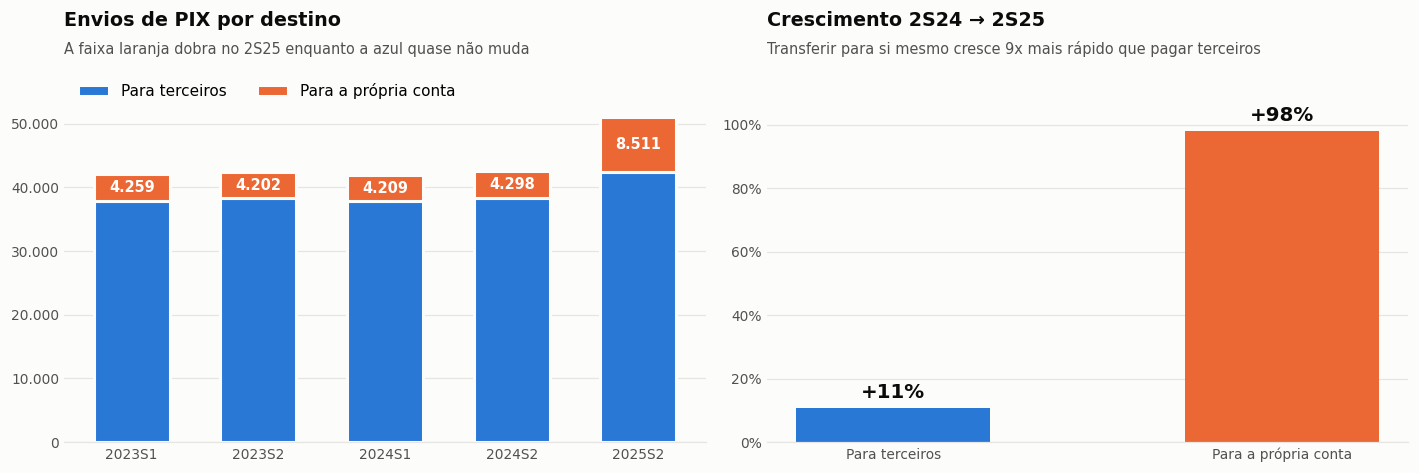

  Dos 8.375 envios a mais no 2S25, 4.213 são para a própria conta
  (50% do crescimento) — sendo que essa categoria era só 10% da base.


In [10]:
# =============================================================================
# H7.1 — A conta se sustenta sobre a base tratada?
# =============================================================================
envios = PIX_OK[PIX_OK.Tipo_transacao == 'Envio']

versoes = {}
versoes['Base tratada']                  = envios
versoes['+ excluindo flag_antes_da_conta'] = envios[~envios.flag_antes_da_conta]

comp = pd.DataFrame({
    nome: (100*v.groupby('semestre').Pix_para_si_mesmo.mean()).round(1)
    for nome, v in versoes.items()})
comp['Envios (base tratada)'] = envios.groupby('semestre').size()
comp['Para si mesmo (nº)']    = envios.groupby('semestre').Pix_para_si_mesmo.sum()
comp['Ticket normalizado']    = envios.groupby('semestre').Valor_norm.median().round(2)
display(comp.style.format({'Envios (base tratada)':'{:,.0f}','Para si mesmo (nº)':'{:,.0f}',
                           'Ticket normalizado':'R$ {:,.2f}'}))

print('  → O salto de 10,1% para 16,7% sobrevive a todas as exclusões de flag.')
print('  → E o ticket fica constante (R$ 153 a R$ 156), o que confirma que a normalização funcionou:')
print('    não é que os PIX ficaram maiores, é que ficaram MAIS.')

# =============================================================================
# H7.2 — Decompondo o crescimento: quem cresceu, terceiros ou a própria conta?
# =============================================================================
d7 = envios.groupby('semestre').agg(para_si=('Pix_para_si_mesmo','sum'), total=('id_pix','size'))
d7['terceiros'] = d7.total - d7.para_si
delta = d7.loc['2025S2'] - d7.loc['2024S2']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
x = np.arange(len(d7))
ax.bar(x, d7.terceiros, width=0.6, color=BLUE, label='Para terceiros', edgecolor=SURF, linewidth=2)
ax.bar(x, d7.para_si, bottom=d7.terceiros, width=0.6, color=ORANGE, label='Para a própria conta',
       edgecolor=SURF, linewidth=2)
for i, (t, s) in enumerate(zip(d7.terceiros, d7.para_si)):
    ax.text(i, t + s/2, n(s), ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')
ax.set_xticks(x, d7.index); ax.set_ylim(0, d7.total.max()*1.15)
ax.yaxis.set_major_formatter(FMT_MIL); ax.legend(loc='upper left', ncols=2)
eixo(ax, 'Envios de PIX por destino', 'A faixa laranja dobra no 2S25 enquanto a azul quase não muda')

ax = axes[1]
crescimento = pd.Series({'Para terceiros': 100*(d7.loc['2025S2','terceiros']/d7.loc['2024S2','terceiros']-1),
                         'Para a própria conta': 100*(d7.loc['2025S2','para_si']/d7.loc['2024S2','para_si']-1)})
ax.bar(range(2), crescimento.values, width=0.5, color=[BLUE, ORANGE])
ax.set_xticks(range(2), crescimento.index)
for i, v in enumerate(crescimento.values):
    ax.text(i, v + 3, f'{v:+.0f}%', ha='center', fontsize=13, fontweight='bold', color=INK)
ax.set_ylim(0, crescimento.max()*1.20); ax.yaxis.set_major_formatter(FMT_PCT)
eixo(ax, 'Crescimento 2S24 → 2S25', 'Transferir para si mesmo cresce 9x mais rápido que pagar terceiros')

plt.tight_layout(); plt.show()

print(f'  Dos {n(int(delta.total))} envios a mais no 2S25, {n(int(delta.para_si))} são para a própria conta')
print(f'  ({100*delta.para_si/delta.total:.0f}% do crescimento) — sendo que essa categoria era só 10% da base.')

O problema é que o salto existe. Mas ele acontece entre 2S24 e 2S25 porque não temos dados de 
2025S1  e 2025S2 é exatamente o semestre em que a extração da base mudou.

Existe uma explicação que os dados não permitem descartar: se o novo processo de extração
passou a capturar um tipo de transação que antes não entrava (transferências entre contas de mesma
titularidade são um forte candidato, porque muitos sistemas as classificam separadamente) então tanto
o volume a mais quanto a proporção a mais vêm do cano, não do cliente.

Para separar as duas coisas precisariamos dos sete meses que faltam.

In [21]:
veredito(7, 'PIX para a própria conta subiu de 10% para 16%', 'NÃO CONCLUSIVA',
 'O número está certo e é robusto: 10,1% no 2S24 para 16,7% no 2S25, sobrevivendo à exclusão de todas '
 'as flags, com ticket normalizado constante (R$ 153-156) e crescimento desproporcional — a categoria '
 'dobra (+98%) enquanto envios a terceiros sobem 11%, e responde por metade de todo o crescimento apesar '
 'de ser 10% da base. Mas o salto acontece no mesmo semestre da quebra de extração, e existe uma '
 'explicação rival que os dados não permitem descartar: o novo processo pode ter passado a capturar '
 'transferências entre contas próprias que antes não entravam. Usar como evidência de APOIO, nunca como '
 'prova isolada. Para confirmar, é preciso pedir ao banco os 7 meses faltantes ou a documentação da '
 'mudança de agosto de 2025.')


════════════════════════════════════════════════════════════════════════════
    H7 — NÃO CONCLUSIVA
────────────────────────────────────────────────────────────────────────────
  O número está certo e é robusto: 10,1% no 2S24 para 16,7% no 2S25, sobrevivendo à exclusão de todas as flags, com ticket normalizado constante (R$ 153-156) e crescimento desproporcional — a categoria dobra (+98%) enquanto envios a terceiros sobem 11%, e responde por metade de todo o crescimento apesar de ser 10% da base. Mas o salto acontece no mesmo semestre da quebra de extração, e existe uma explicação rival que os dados não permitem descartar: o novo processo pode ter passado a capturar transferências entre contas próprias que antes não entravam. Usar como evidência de APOIO, nunca como prova isolada. Para confirmar, é preciso pedir ao banco os 7 meses faltantes ou a documentação da mudança de agosto de 2025.
════════════════════════════════════════════════════════════════════════════


---
# 8 · O cadastro incompleto impede o cliente de investir

> Vendo que os clientes com infromação incompleta não investem, pensamos que o cadastro pode ser um processo com atrito, ou seja, um processo complexo demais, que empurra o cliente a investir em outro banco com processo mais simples.


| Rival | Se for verdade |
|---|---|
| **São clientes novos** que ainda não completaram o cadastro | a hipótese vira "questão de tempo", não de atrito |
| **Causalidade reversa**: o banco só pede renda quando o cliente vai investir | o campo vazio é *consequência* de não investir, não causa |

,clientes,usa_cartao,usa_pix,investe,meses_de_casa
Renda informada,"1,705",73.0%,72.8%,58.0%,34
Renda AUSENTE,255,73.3%,74.1%,5.5%,34


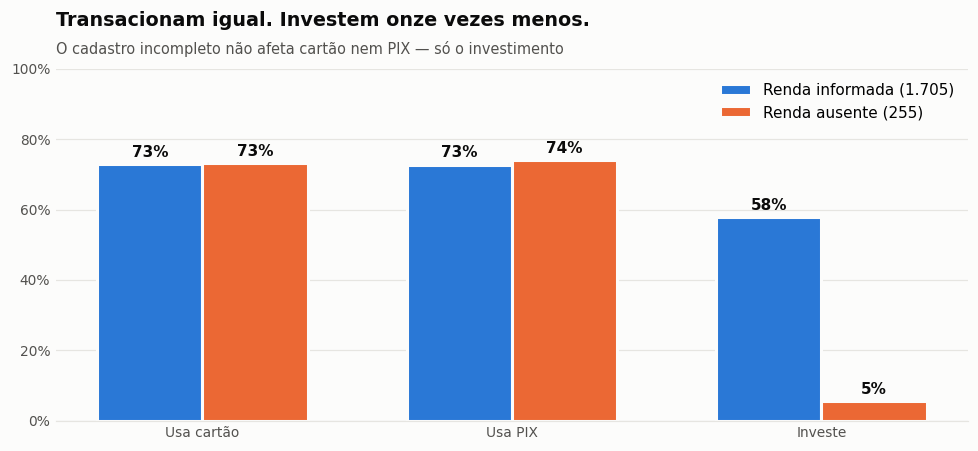

,Renda informada,Renda ausente,% incompleto
Data_Criacao_Conta,,,
2023,1344,203,13.1
2024,198,26,11.6
2025,163,26,13.8


  Tempo de casa mediano — com renda: 34 meses  |  sem renda: 34 meses

  → A proporção de cadastro incompleto é ~13% em TODAS as safras, de 2023 a 2025.
  → E o tempo de casa é idêntico. Não são clientes novos.
  → RIVAL 1 DESCARTADA.
  Se o banco só coletasse a renda no momento de investir, esperaríamos:
    · 100% dos investidores com renda preenchida  →  observado: 98.6%
    · quase 0% dos NÃO investidores com renda     →  observado: 74.8%

  Investidores COM cadastro incompleto: 14
    → Se a renda fosse pré-requisito absoluto, seria zero. Não é um bloqueio técnico rígido.

  E 75% de quem NÃO investe tem a renda preenchida.
    → Ou seja, o banco coleta renda de gente que nunca investiu. A coleta não depende de investir.

  → RIVAL 2 ENFRAQUECIDA: a renda claramente não é coletada apenas na hora de investir.


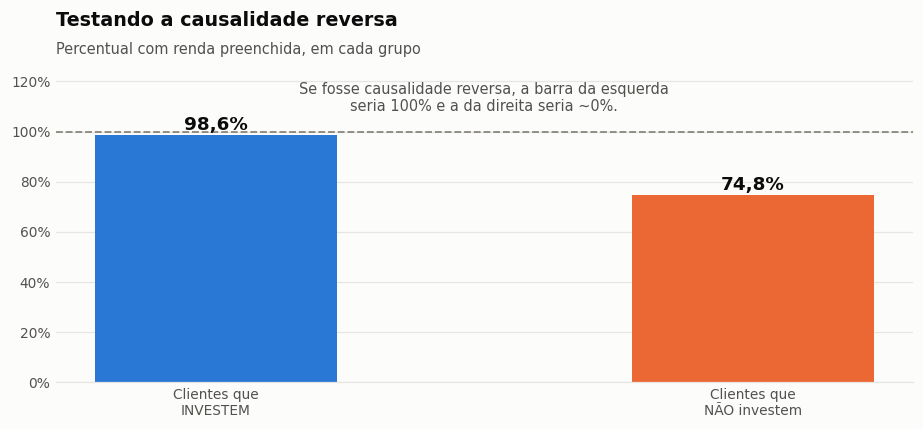


════════════════════════════════════════════════════════════════════════════
    H8 — CONFIRMADA
────────────────────────────────────────────────────────────────────────────
  A associação é forte e as duas explicações rivais caem. Os 255 clientes sem renda usam cartão (73,3%) e PIX (74,1%) exatamente como os demais, mas só 5,5% investem contra 58,0% — onze vezes menos. RIVAL 1 (são clientes novos): descartada, a proporção de cadastro incompleto é ~13% em todas as safras e o tempo de casa mediano é idêntico (34 meses). RIVAL 2 (o banco só pede renda na hora de investir): enfraquecida, porque 74,8% de quem NUNCA investiu tem renda preenchida, e existem 14 investidores com cadastro incompleto — não é um bloqueio técnico absoluto. A explicação de POR QUE o cadastro fica incompleto (atrito no onboarding) é plausível mas NÃO testável aqui: seriam necessários dados de funil de cadastro que a base não tem.
════════════════════════════════════════════════════════════════════════════


In [ ]:
# =============================================================================
# H8.1 — A associação existe?
# =============================================================================
clientes['investe']    = clientes.Cliente_ID.isin(invest.Cliente_ID)
clientes['usa_cartao'] = clientes.Cliente_ID.isin(transac.Cliente_ID)
clientes['usa_pix']    = clientes.Cliente_ID.isin(pix.Cliente_ID)

comp8 = clientes.groupby('cadastro_incompleto').agg(
    clientes=('Cliente_ID','size'), usa_cartao=('usa_cartao','mean'),
    usa_pix=('usa_pix','mean'), investe=('investe','mean'), meses_de_casa=('meses_de_casa','median'))
comp8.index = ['Renda informada', 'Renda AUSENTE']
display(comp8.style.format({'clientes':'{:,.0f}','usa_cartao':'{:.1%}','usa_pix':'{:.1%}',
                            'investe':'{:.1%}','meses_de_casa':'{:.0f}'}))

fig, ax = plt.subplots(figsize=(9, 4.2))
larg, xs = 0.34, np.arange(3)
v0 = 100*comp8.iloc[0][['usa_cartao','usa_pix','investe']].values.astype(float)
v1 = 100*comp8.iloc[1][['usa_cartao','usa_pix','investe']].values.astype(float)
ax.bar(xs - larg/2, v0, larg, color=BLUE,   label='Renda informada (1.705)', edgecolor=SURF, linewidth=2)
ax.bar(xs + larg/2, v1, larg, color=ORANGE, label='Renda ausente (255)',      edgecolor=SURF, linewidth=2)
for i in xs:
    ax.text(i - larg/2, v0[i] + 2, f'{v0[i]:.0f}%', ha='center', fontsize=10, fontweight='bold', color=INK)
    ax.text(i + larg/2, v1[i] + 2, f'{v1[i]:.0f}%', ha='center', fontsize=10, fontweight='bold', color=INK)
ax.set_xticks(xs, ['Usa cartão', 'Usa PIX', 'Investe']); ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(FMT_PCT); ax.legend(loc='upper right')
eixo(ax, 'Transacionam igual. Investem onze vezes menos.',
        'O cadastro incompleto não afeta cartão nem PIX — só o investimento')
plt.tight_layout(); plt.show()

# =============================================================================
# H8.2 — Rival 1: são clientes novos que ainda não tiveram tempo?
# =============================================================================
por_safra = clientes.groupby([clientes.Data_Criacao_Conta.dt.year, 'cadastro_incompleto']).size().unstack(fill_value=0)
por_safra.columns = ['Renda informada', 'Renda ausente']
por_safra['% incompleto'] = (100*por_safra['Renda ausente']/por_safra.sum(axis=1)).round(1)
display(por_safra)

print(f'  Tempo de casa mediano — com renda: {comp8.meses_de_casa.iloc[0]:.0f} meses  |  '
      f'sem renda: {comp8.meses_de_casa.iloc[1]:.0f} meses')
print()
print('  → A proporção de cadastro incompleto é ~13% em TODAS as safras, de 2023 a 2025.')
print('  → E o tempo de casa é idêntico. Não são clientes novos.')
print('  → RIVAL 1 DESCARTADA.')

# =============================================================================
# H8.3 — Rival 2: causalidade reversa? (o banco só pede renda na hora de investir)
# =============================================================================
com_renda_investe     = 100*(~clientes.loc[clientes.investe, 'cadastro_incompleto']).mean()
com_renda_nao_investe = 100*(~clientes.loc[~clientes.investe, 'cadastro_incompleto']).mean()
investidores_sem_renda = int(clientes[clientes.investe].cadastro_incompleto.sum())

print('  Se o banco só coletasse a renda no momento de investir, esperaríamos:')
print(f'    · 100% dos investidores com renda preenchida  →  observado: {com_renda_investe:.1f}%')
print(f'    · quase 0% dos NÃO investidores com renda     →  observado: {com_renda_nao_investe:.1f}%')
print()
print(f'  Investidores COM cadastro incompleto: {investidores_sem_renda}')
print('    → Se a renda fosse pré-requisito absoluto, seria zero. Não é um bloqueio técnico rígido.')
print()
print(f'  E {com_renda_nao_investe:.0f}% de quem NÃO investe tem a renda preenchida.')
print('    → Ou seja, o banco coleta renda de gente que nunca investiu. A coleta não depende de investir.')
print()
print('  → RIVAL 2 ENFRAQUECIDA: a renda claramente não é coletada apenas na hora de investir.')

fig, ax = plt.subplots(figsize=(8.5, 4))
vals = [com_renda_investe, com_renda_nao_investe]
ax.bar([0, 1], vals, width=0.45, color=[BLUE, ORANGE])
ax.set_xticks([0, 1], ['Clientes que\nINVESTEM', 'Clientes que\nNÃO investem'])
for i, v in enumerate(vals):
    ax.text(i, v + 2, f'{v:.1f}%'.replace('.', ','), ha='center', fontsize=12, fontweight='bold', color=INK)
ax.axhline(100, color=INK3, ls='--', lw=1.2)
ax.annotate('Se fosse causalidade reversa, a barra da esquerda\nseria 100% e a da direita seria ~0%.',
            (0.5, 108), ha='center', fontsize=9.5, color=INK2)
ax.set_ylim(0, 125); ax.yaxis.set_major_formatter(FMT_PCT)
eixo(ax, 'Testando a causalidade reversa', 'Percentual com renda preenchida, em cada grupo')
plt.tight_layout(); plt.show()

veredito(8, 'O cadastro incompleto impede o cliente de investir', 'CONFIRMADA',
 'A associação é forte e as duas explicações rivais caem. Os 255 clientes sem renda usam cartão (73,3%) '
 'e PIX (74,1%) exatamente como os demais, mas só 5,5% investem contra 58,0% , onze vezes menos. '
 'RIVAL 1 (são clientes novos): descartada, a proporção de cadastro incompleto é ~13% em todas as '
 'safras e o tempo de casa mediano é idêntico (34 meses). RIVAL 2 (o banco só pede renda na hora de '
 'investir): enfraquecida, porque 74,8% de quem NUNCA investiu tem renda preenchida, e existem 14 '
 'investidores com cadastro incompleto — não é um bloqueio técnico absoluto. A explicação de POR QUE o '
 'cadastro fica incompleto (atrito no onboarding) é plausível mas NÃO testável aqui: seriam necessários '
 'dados de funil de cadastro que a base não tem.')

---
# 9 · O dinheiro está saindo pelos investimentos. Ou mas os picos são de fim de ano?

> Nossa hipótese já vem com uma dúvida, mas decidimos testar, já que também poderia ser uma melhora que poderiamos recomendar para o banco se fosse o caso

Então vamos ver, O dinheiro está mesmo saindo?

1. A captação líquida (aportes menos resgates) é negativa em algum trimestre?
2. O aumento dos resgates é sazonalidade de fim de ano? Podemos comparar o padrão mensal entre os anos;
3. Se não é sazonalidade, que forma tem?

,Aportes,Resgates,Liquido,Pct_resgate
trim,,,,
2023Q1,"R$ 2,259,732","R$ 23,814","R$ 2,235,918",2.1%
2023Q2,"R$ 3,139,304","R$ 27,082","R$ 3,112,221",2.2%
2023Q3,"R$ 3,542,753","R$ 25,066","R$ 3,517,687",2.3%
2023Q4,"R$ 4,354,857","R$ 38,612","R$ 4,316,245",1.8%
2024Q1,"R$ 3,847,442","R$ 676,761","R$ 3,170,682",7.8%
2024Q2,"R$ 3,670,774","R$ 613,553","R$ 3,057,221",8.8%
2024Q3,"R$ 3,560,225","R$ 1,301,915","R$ 2,258,309",11.8%
2024Q4,"R$ 3,272,531","R$ 1,209,921","R$ 2,062,609",12.1%
2025Q1,"R$ 5,066,088","R$ 862,309","R$ 4,203,779",4.6%


  Trimestres com captação líquida NEGATIVA: 0 de 12
  Pior trimestre da série: 4T25 com R$ 1.686.185,33 — ainda POSITIVO
  Soma dos 12 trimestres: R$ 36.907.165,71 entraram a mais do que saíram

  → Em NENHUM trimestre saiu mais dinheiro do que entrou.
  → O dinheiro não está saindo. O que caiu foi a VELOCIDADE com que entra.


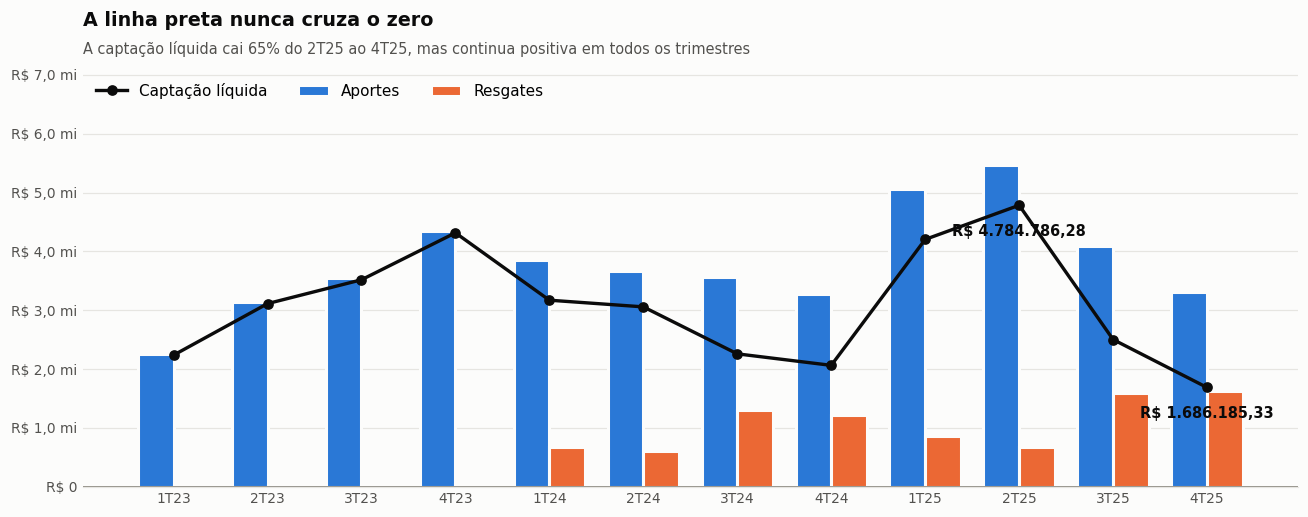

S,S1,S2,Diferença S2 − S1
ano,,,
2023,2.2,2.0,-0.2
2024,8.3,11.9,3.6
2025,4.7,13.7,9.0


  Correlação entre os perfis mensais de anos consecutivos:
    2023 x 2024 : -0.146
    2024 x 2025 : +0.843

  → Sazonalidade de verdade se repete: a diferença S2−S1 seria parecida todo ano.
    Observado: -0,1 p.p. em 2023, +3,6 em 2024, +9,0 em 2025. Não se repete, cresce.
  → E 2023 não tem correlação nenhuma com 2024. Não existe um padrão de calendário estável.


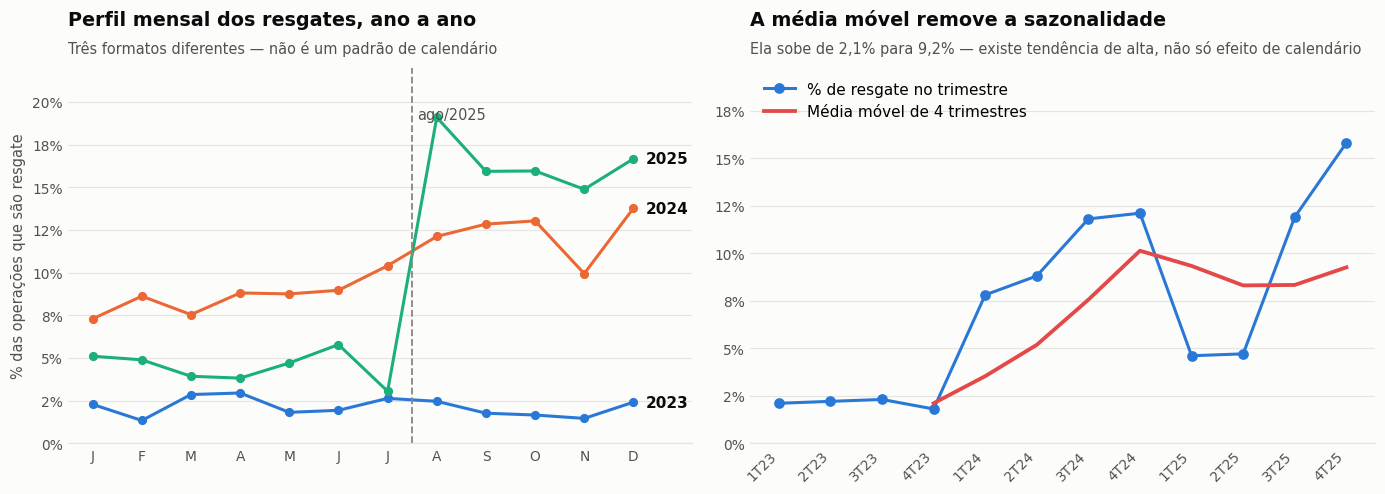

  Perfil mensal de 2025: 3-6% de janeiro a julho, e 19,1% em agosto.
  → Não é um pico de dezembro. É um DEGRAU em agosto — a mesma data da quebra do PIX.


In [23]:
# =============================================================================
# H9.1 — A pergunta que vem antes: o dinheiro está saindo?
# =============================================================================
fluxo = (invest.assign(aporte=invest.Valor_Aplicado.clip(lower=0),
                       resgate=-invest.Valor_Aplicado.clip(upper=0),
                       eh_resgate=invest.Valor_Aplicado < 0)
         .groupby('trim').agg(Aportes=('aporte','sum'), Resgates=('resgate','sum'),
                              Operacoes=('Cliente_ID','size'), Pct_resgate=('eh_resgate','mean')))
fluxo['Liquido'] = fluxo.Aportes - fluxo.Resgates
fluxo['Pct_resgate'] = (100*fluxo.Pct_resgate).round(1)

display(fluxo[['Aportes','Resgates','Liquido','Pct_resgate']].style.format(
    {'Aportes':'R$ {:,.0f}','Resgates':'R$ {:,.0f}','Liquido':'R$ {:,.0f}','Pct_resgate':'{:.1f}%'}))

print(f'  Trimestres com captação líquida NEGATIVA: {(fluxo.Liquido < 0).sum()} de {len(fluxo)}')
print(f'  Pior trimestre da série: {rot_trim(fluxo.Liquido.idxmin())} com {brl(fluxo.Liquido.min())} — '
      f'ainda POSITIVO')
print(f'  Soma dos 12 trimestres: {brl(fluxo.Liquido.sum())} entraram a mais do que saíram')
print()
print('  → Em NENHUM trimestre saiu mais dinheiro do que entrou.')
print('  → O dinheiro não está saindo. O que caiu foi a VELOCIDADE com que entra.')

fig, ax = plt.subplots(figsize=(12, 4.8))
x = np.arange(len(fluxo)); larg = 0.38
ax.bar(x - larg/2, fluxo.Aportes,  larg, color=BLUE,   label='Aportes',  edgecolor=SURF, linewidth=2)
ax.bar(x + larg/2, fluxo.Resgates, larg, color=ORANGE, label='Resgates', edgecolor=SURF, linewidth=2)
ax.plot(x, fluxo.Liquido, color=INK, marker='o', lw=2.2, label='Captação líquida')
ax.axhline(0, color=INK3, lw=1.2)
for i in (fluxo.Liquido.values.argmax(), len(x)-1):
    ax.annotate(brl(fluxo.Liquido.iloc[i]).replace(',00',''), (x[i], fluxo.Liquido.iloc[i]),
                xytext=(0, -20), textcoords='offset points', ha='center',
                fontsize=9.5, fontweight='bold', color=INK)
ax.set_xticks(x, [rot_trim(p) for p in fluxo.index]); ax.set_ylim(0, fluxo.Aportes.max()*1.30)
ax.yaxis.set_major_formatter(FMT_BRL); ax.legend(loc='upper left', ncols=3)
eixo(ax, 'A linha preta nunca cruza o zero',
        'A captação líquida cai 65% do 2T25 ao 4T25, mas continua positiva em todos os trimestres')
plt.tight_layout(); plt.show()

# =============================================================================
# H9.2 — É sazonalidade de fim de ano?
# =============================================================================
# Teste 1: a diferença entre 2º e 1º semestre é parecida todos os anos?
sem = (invest.assign(eh=invest.Valor_Aplicado < 0, S=np.where(invest.mes > 6, 'S2', 'S1'))
       .pivot_table(index='ano', columns='S', values='eh', aggfunc='mean')*100).round(1)
sem['Diferença S2 − S1'] = (sem.S2 - sem.S1).round(1)
display(sem)

# Teste 2: o perfil mensal de um ano parece com o do outro?
perfil = (invest.assign(eh=invest.Valor_Aplicado < 0)
          .pivot_table(index='mes', columns='ano', values='eh', aggfunc='mean')*100)

print('  Correlação entre os perfis mensais de anos consecutivos:')
print(f'    2023 x 2024 : {perfil[2023].corr(perfil[2024]):+.3f}')
print(f'    2024 x 2025 : {perfil[2024].corr(perfil[2025]):+.3f}')
print()
print('  → Sazonalidade de verdade se repete: a diferença S2−S1 seria parecida todo ano.')
print('    Observado: -0,1 p.p. em 2023, +3,6 em 2024, +9,0 em 2025. Não se repete, cresce.')
print('  → E 2023 não tem correlação nenhuma com 2024. Não existe um padrão de calendário estável.')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

ax = axes[0]
cores_ano = {2023: BLUE, 2024: ORANGE, 2025: AQUA}
for ano in (2023, 2024, 2025):
    ax.plot(perfil.index, perfil[ano], color=cores_ano[ano], marker='o', markersize=5, label=str(ano))
    ax.annotate(str(ano), (12, perfil.loc[12, ano]), xytext=(8, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color=INK, va='center')
ax.axvline(7.5, color=INK3, ls='--', lw=1.2)
ax.annotate('ago/2025', (7.6, 19), fontsize=9.5, color=INK2)
ax.set_xticks(range(1, 13), ['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_ylim(0, 22); ax.yaxis.set_major_formatter(FMT_PCT); ax.set_xlim(0.5, 13.2)
eixo(ax, 'Perfil mensal dos resgates, ano a ano',
        'Três formatos diferentes — não é um padrão de calendário', ylab='% das operações que são resgate')

ax = axes[1]
x = np.arange(len(fluxo))
ax.plot(x, fluxo.Pct_resgate, color=BLUE, marker='o', label='% de resgate no trimestre')
mm = fluxo.Pct_resgate.rolling(4).mean()
ax.plot(x, mm, color=RED, lw=2.5, label='Média móvel de 4 trimestres')
ax.set_xticks(x, [rot_trim(p) for p in fluxo.index], rotation=45, ha='right')
ax.set_ylim(0, fluxo.Pct_resgate.max()*1.25); ax.yaxis.set_major_formatter(FMT_PCT)
ax.legend(loc='upper left')
eixo(ax, 'A média móvel remove a sazonalidade',
        'Ela sobe de 2,1% para 9,2% — existe tendência de alta, não só efeito de calendário')

plt.tight_layout(); plt.show()

print('  Perfil mensal de 2025: 3-6% de janeiro a julho, e 19,1% em agosto.')
print('  → Não é um pico de dezembro. É um DEGRAU em agosto — a mesma data da quebra do PIX.')

### O degrau de agosto de 2025 merece uma linha de atenção

Os resgates de investimento saltam de 3,0% em julho para 19,1% em agosto de 2025 e ficam nesse
patamar. É exatamente o mês em que a base PIX volta de sete meses de vazio e muda de escala.

Duas bases independentes mudando de comportamento no mesmo primeiro dia de mês é um sinal de alerta
sobre a disponibilidade dos dados, não necessariamente sobre o cliente. A base de investimentos passou no
teste de escala, mas a coincidência de datas precisa ser investigada.

In [25]:
veredito(9, 'O dinheiro está saindo pelos investimentos', 'REFUTADA',
 'A captação líquida é POSITIVA em todos os 12 trimestres, em nenhum momento saiu mais dinheiro do que '
 'entrou, e o pior trimestre da série (4T25) ainda soma R$ 1,69 mi de entrada líquida. O dinheiro não '
 'está saindo; o que caiu foi a velocidade com que entra (-65% do 2T25 ao 4T25). Sobre a dúvida da '
 'sazonalidade: ela também não se confirma. A diferença entre 2º e 1º semestre é pouca. em 2023, '
 '+3,6 em 2024 e +9,0 em 2025, não se repete, cresce: e os perfis mensais de 2023 e 2024 não têm '
 'correlação. O que existe é tendência de alta (média móvel de 2,1% para 9,2%) mais um degrau abrupto '
 'em ago/2025, na mesma data da quebra da base PIX, o que precisa ser chacado')


════════════════════════════════════════════════════════════════════════════
    H9 — REFUTADA
────────────────────────────────────────────────────────────────────────────
  A captação líquida é POSITIVA em todos os 12 trimestres, em nenhum momento saiu mais dinheiro do que entrou, e o pior trimestre da série (4T25) ainda soma R$ 1,69 mi de entrada líquida. O dinheiro não está saindo; o que caiu foi a velocidade com que entra (-65% do 2T25 ao 4T25). Sobre a dúvida da sazonalidade: ela também não se confirma. A diferença entre 2º e 1º semestre é pouca. em 2023, +3,6 em 2024 e +9,0 em 2025, não se repete, cresce: e os perfis mensais de 2023 e 2024 não têm correlação. O que existe é tendência de alta (média móvel de 2,1% para 9,2%) mais um degrau abrupto em ago/2025, na mesma data da quebra da base PIX, o que precisa ser chacado
════════════════════════════════════════════════════════════════════════════


## Portanto

Depois de tudo, três afirmações se sustentam calramente:

1. O banco nunca foi o principal do cliente. Sem salário entrando, saindo 7,4× mais do que
   entra, e nenhum dos 1.430 clientes com fluxo líquido positivo.
2. Não há churn, há esvaziamento de uso. Carteira -3%, frequência -48%.
3. Um campo de cadastro em branco bloqueia a venda de investimento. Onze vezes menos, com as
   duas explicações rivais testadas e descartadas.

E duas refutações valem mais que as hipóteses originais:

- A terceira hipótese apontava para "melhorar o cartão". O teste mostrou que o cartão sai junto com a conta e que a
  emissão parou porque a aquisição parou. O alvo muda de produto para funil de entrada.
- Já a nona, apontava para "o dinheiro está fugindo". A captação líquida nunca ficou negativa. O problema é
  desaceleração, não fuga, o que pede uma resposta diferente.

## Um ponto importante que só percebemos no final

A emissão de cartões cessa completamente em maio de 2025,  zero cartões emitidos nos últimos sete
meses da série, enquanto o banco continuou abrindo contas (53 no 2S25). Cliente novo entrando e não
recebendo cartão.

Isso não é comportamento de cliente. Parece ser uma falha na decisão interna ou na política de crédito.